# **Time Series Analysis**

In this notebook general concepts about time series will be analysed: mean, autocovariance, autocorrelation, stationarity, smoothing, trend (removal), seasonality (removal), forecasting, MA(q), AR(p), ARMA(p, q), ARIMA(p, q). 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import typing as t
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

## **Stationarity**

### **Common Stationary and Nonstationary Time Series**

Weak Stationarity: a time series $X$ is weakly stationary if:
- the mean is constant over time $E[X(t)] = m, \forall t \in T$
- the variance is finite $E[X(t)^2] < \infty, \forall t \in T$ 
- the covariance of $X(t)$ and $X(t + h)$ depends only on h, i.e., is shift-invariance in time

In [14]:
def run_sequence_plot(x, y, title, xlabel="Time", ylabel="Values", ax=None):
    if ax is None:
        _, ax = plt.subplots(1,1, figsize=(10, 3.5))
    ax.plot(x, y, 'k-')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    return ax

#### **Stationary Time Series**

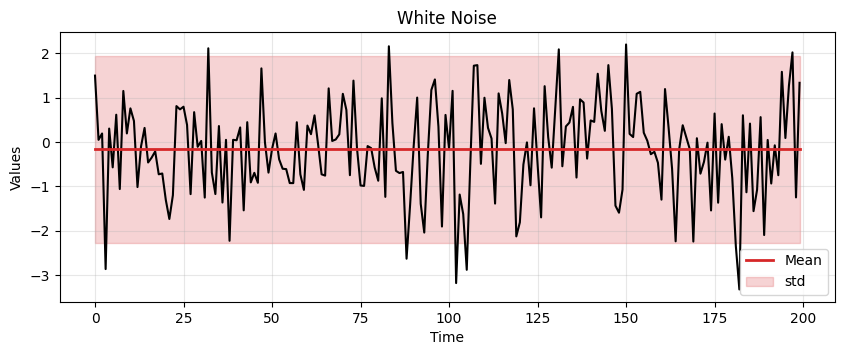

In [15]:
T = 200
time = np.arange(T)
white_noise = np.random.normal(loc=0, scale=1.0, size=(T))

ax = run_sequence_plot(time, white_noise, title="White Noise")
ax.plot(time, np.ones_like(time) * np.mean(white_noise), linewidth=2, color="tab:red", label="Mean")
ax.fill_between(
    time, 
    np.ones_like(time) * (white_noise.mean() - 1.96 * white_noise.std()), 
    np.ones_like(time) * (white_noise.mean() + 1.96 * white_noise.std()), 
    color='tab:red', 
    alpha=0.2,
    label='std'
)
plt.legend()

#### **Nonstationary Time Series**

<Axes: title={'center': 'Random Walk'}, xlabel='Time', ylabel='Values'>

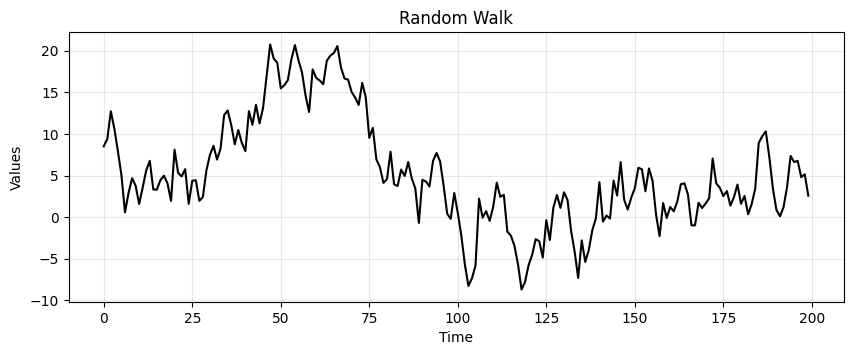

In [16]:
seed = 3.14
random_walk = np.empty_like(time, dtype='float')
for t in time:
    random_walk[t] = seed + np.random.normal(loc=0, scale=2.5, size=1)[0]
    seed = random_walk[t]
run_sequence_plot(time, random_walk, title="Random Walk")

<Axes: title={'center': 'Nonstationary with Trend'}, xlabel='Time', ylabel='Values'>

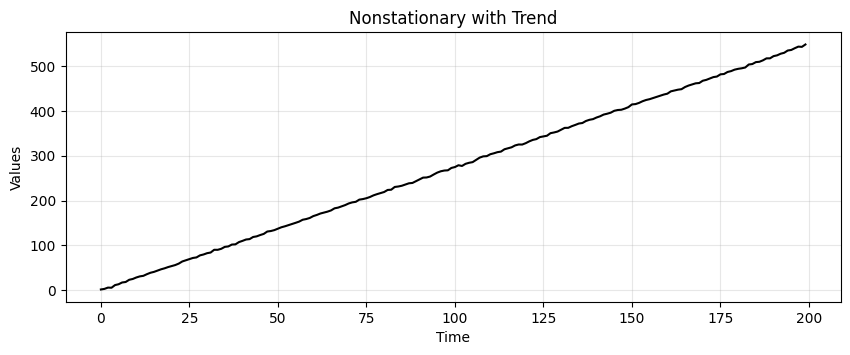

In [17]:
# this is nonstationary because the mean is changing over time
trend = (time * 2.75) + white_noise
run_sequence_plot(time, trend, title="Nonstationary with Trend")

<Axes: title={'center': 'Nonstationary Heteroscedastic'}, xlabel='Time', ylabel='Values'>

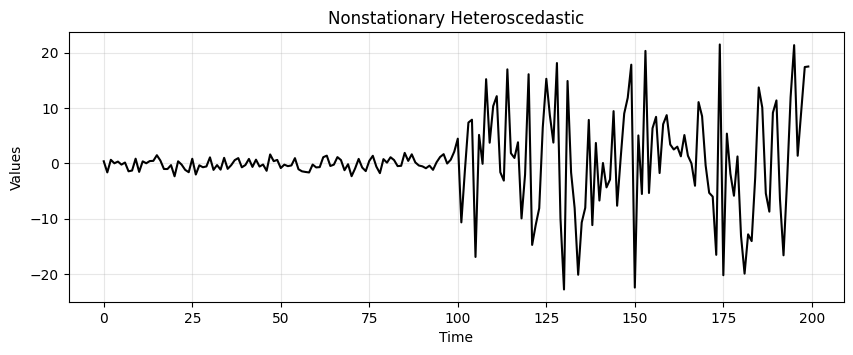

In [18]:
# this is nonstationary because the variance changes over time
first = np.random.normal(loc=0, scale=1.0, size=(T // 2))
second = np.random.normal(loc=0, scale=10.0, size=(T // 2))
heteroscedastic = np.append(first, second)
run_sequence_plot(time, heteroscedastic, title="Nonstationary Heteroscedastic")

### **Augmented Dickey-Fuller Test**

A statistical procedure to determine whether a time series is stationary or not. The hypotheses implied by this test are:
- **null hypothesis**: $H_0$ the series is nonstationary.
- **alternative hypothesis**: $H_A$ the series is stationary.

The values $\alpha = 0.05$ or $\alpha = 0.01$, which yield a confidence $95$% and $99$% are a common choice for the confidence interval.

*Example:* $p = 0.0001$ reject $H_0$, results that the time series is *stationary*

*Example:* $p = 0.43$ fail to reject $H_0$, results that the time series is *non-stationary*



In [19]:
adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(trend, regression='c')

print("Augmented Dickey Fuller for Trend Time Series")
print("---------------------------------------------")
print(f"ADF: {adf:.4f}")
print(f"p-value: {pvalue:.4f}")
print(f"nobs (number of observations): {nobs}")
print(f"critical values: {critical_values}")

Augmented Dickey Fuller for Trend Time Series
---------------------------------------------
ADF: 0.4537
p-value: 0.9834
nobs (number of observations): 184
critical values: {'1%': -3.466398230774071, '5%': -2.8773796387256514, '10%': -2.575213838610586}


In [20]:
adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(white_noise, regression='c')

print("Augmented Dickey Fuller for White Noise Series")
print("---------------------------------------------")
print(f"ADF: {adf:.4f}")
print(f"p-value: {pvalue:.4f}")
print(f"nobs (number of observations): {nobs}")
print(f"critical values: {critical_values}")

Augmented Dickey Fuller for White Noise Series
---------------------------------------------
ADF: -13.2267
p-value: 0.0000
nobs (number of observations): 199
critical values: {'1%': -3.4636447617687436, '5%': -2.8761761179270766, '10%': -2.57457158581854}


In [21]:
adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(heteroscedastic)

print("Augmented Dickey Fuller for Heteroscedastic Time Series")
print("---------------------------------------------")
print(f"ADF: {adf:.4f}")
print(f"p-value: {pvalue:.4f}")
print(f"nobs (number of observations): {nobs}")
print(f"critical values: {critical_values}")

Augmented Dickey Fuller for Heteroscedastic Time Series
---------------------------------------------
ADF: -13.0195
p-value: 0.0000
nobs (number of observations): 199
critical values: {'1%': -3.4636447617687436, '5%': -2.8761761179270766, '10%': -2.57457158581854}


### **Transformations to Achieve Stationarity**

A small subset of the possible ways to transform nonstationary time series:
- *subtract trend*: leads to constant mean
- *apply log*: leads to constant variance
- *differencing*: removes autocorrelation
- *seasonal differencing*: removes periodic component

##### **Subtract Estimated Trend & Seasonality**

In [22]:
trend_decomposition = seasonal_decompose(x=trend, model="additive", period=12)
trend_est_trend = trend_decomposition.trend
trend_est_seasonal = trend_decomposition.seasonal
trend_est_residual = trend_decomposition.resid

<Axes: title={'center': 'Residuals'}, xlabel='Time', ylabel='series'>

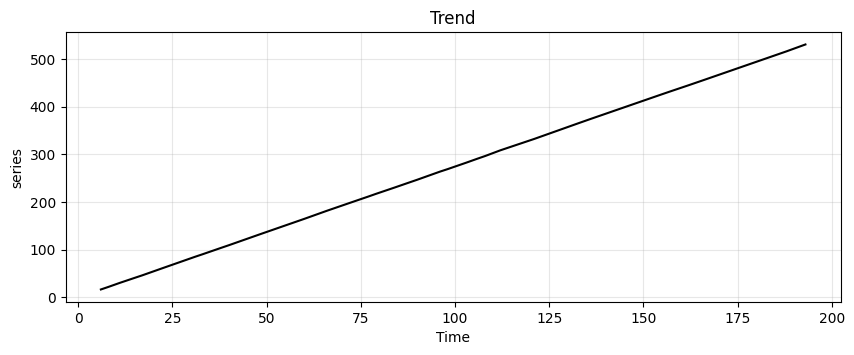

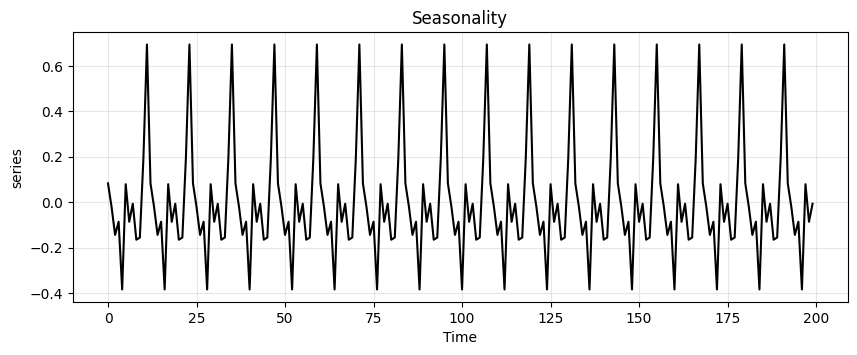

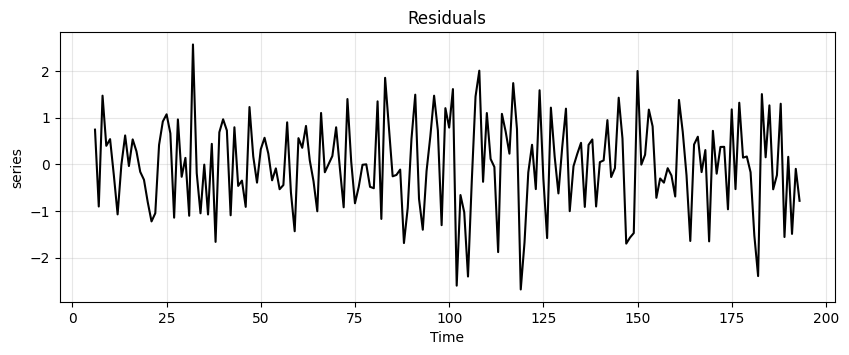

In [23]:
run_sequence_plot(time, trend_est_trend, title="Trend", ylabel="series")
run_sequence_plot(time, trend_est_seasonal, title="Seasonality", ylabel="series")
run_sequence_plot(time, trend_est_residual, title="Residuals", ylabel="series")


In [24]:
adf_after, pvalue_after, _, _, _, _ = adfuller(trend_est_residual[6:-6])

print("Augmented Dickey Fuller for Trend Subtracted")
print("--------------------------------------------")
print(f"ADF: {adf_after:.4f}")
print(f"p-value: {pvalue_after:.4f}")

Augmented Dickey Fuller for Trend Subtracted
--------------------------------------------
ADF: -7.4031
p-value: 0.0000


##### **Stabilize Variance with Log Transform**
- this trick is useful when dealing with heteroskedastic data
- the log squashes the parts of the time series where the variance is higher
- the variance becomes more uniform

<Axes: title={'center': 'Log Heteroskedastic Time Series'}, xlabel='Time', ylabel='Values'>

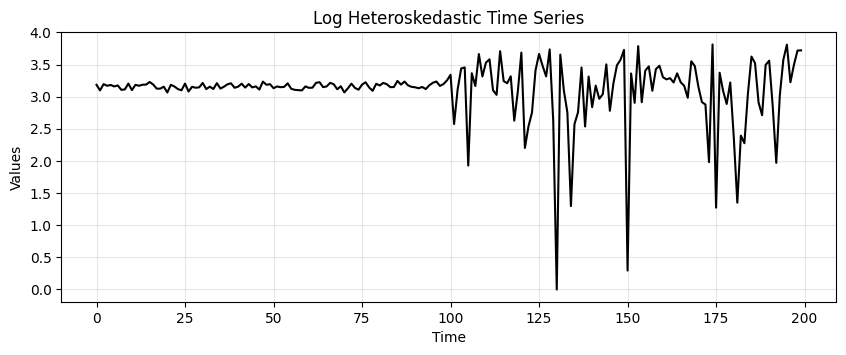

In [25]:
# ensure all data are positive
new_hetero = heteroscedastic - heteroscedastic.min() + 1.0
# apply the log
log_new_hetero = np.log(new_hetero)

run_sequence_plot(time, log_new_hetero, title="Log Heteroskedastic Time Series")

In [26]:
adf_log, pvalue_log, _, _, _, _ = adfuller(log_new_hetero)

print("Augmented Dickey Fuller for Log Heteroscedastic")
print("-----------------------------------------------")
print("A")
print(f"ADF: {adf_log:.4f}")
print(f"p-value: {pvalue_log:.4f}")

Augmented Dickey Fuller for Log Heteroscedastic
-----------------------------------------------
A
ADF: -13.4310
p-value: 0.0000


##### **Removing Autocorrelation with Differencing**

According to the *ADF test*, the Random Walk is a nonstationary time series. We know that the Random Walk was created with a lag of 1. It can be transformed into a stationary time series by applying differencing:

$$X(t) = X(t) - X(t-1)$$

<Axes: title={'center': 'Random Walk after Differencing'}, xlabel='Time', ylabel='Values'>

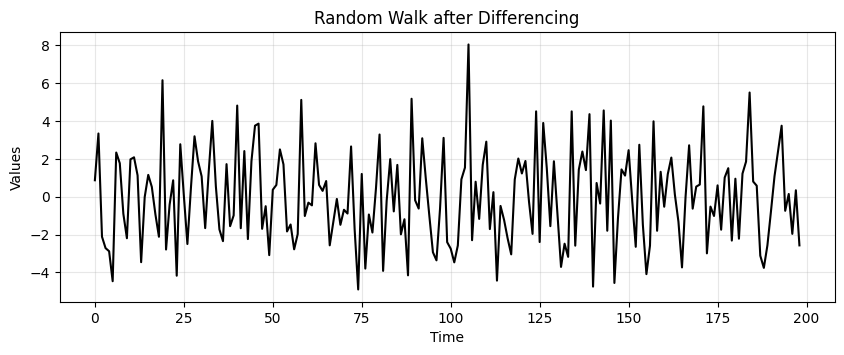

In [27]:
random_walk_diff = random_walk[1:] - random_walk[:-1]
run_sequence_plot(time[:-1], random_walk_diff, title="Random Walk after Differencing")

In [28]:
adf_rw, pvalue_rw, _, _, _, _ = adfuller(random_walk)

print("Augmented Dickey Fuller for Random Walk")
print("---------------------------------------")
print("A")
print(f"ADF: {adf_rw:.4f}")
print(f"p-value: {pvalue_rw:.4f}")

Augmented Dickey Fuller for Random Walk
---------------------------------------
A
ADF: -2.6976
p-value: 0.0744


In [29]:
adf_rwd, pvalue_rwd, _, _, _, _ = adfuller(random_walk_diff)

print("Augmented Dickey Fuller for Random Walk Differencing")
print("---------------------------------------------------")
print("A")
print(f"ADF: {adf_rwd:.4f}")
print(f"p-value: {pvalue_rwd:.4f}")

Augmented Dickey Fuller for Random Walk Differencing
---------------------------------------------------
A
ADF: -8.9845
p-value: 0.0000


## **Smoothing**

A data collection is often affected by noise; if the noise is too strong, it can conceal useful patterns in the data. *Smoothing* is a well-known and often-used technique to recover those patterns by *filtering out noise*. It can also be used to make *forecasts* by projecting the recovered patterns into the future.  

<Axes: title={'center': 'Stationary Time Series'}, xlabel='Time', ylabel='Values'>

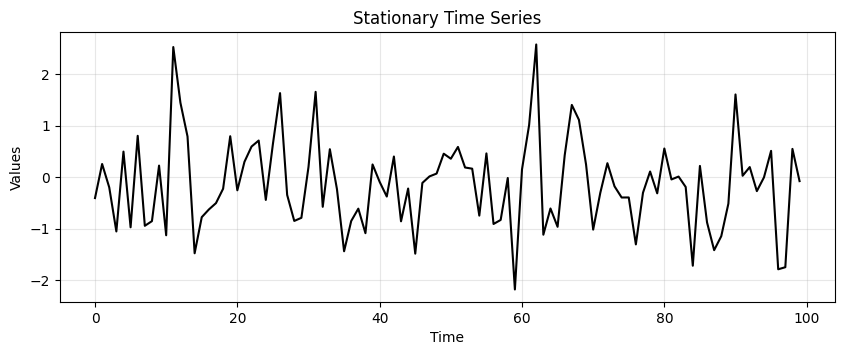

In [30]:
# generate stationary data
time = np.arange(100)
stationary = np.random.normal(loc=0, scale=1.0, size=len(time))
run_sequence_plot(time, stationary, title="Stationary Time Series")

### **Simple Average**

Simple average is the most basic smoothing technique. For the stationary time series above, the most conservative way in which we can represent it is through its *mean*. The *mean* can also be used to predict future values for this time series.

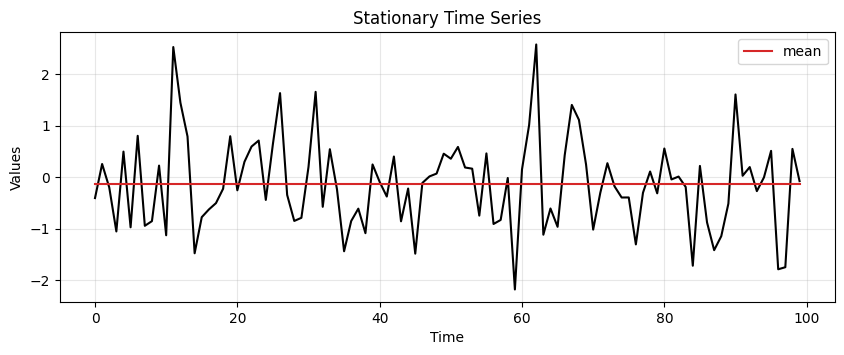

In [31]:
stationary_mean = np.mean(stationary)
stationary_mean_vec = np.full(shape=len(time), fill_value=stationary_mean, dtype='float')

ax = run_sequence_plot(time, stationary, title="Stationary Time Series")
ax.plot(time, stationary_mean_vec, 'tab:red', label="mean")
plt.legend()

### **Moving Average**

In [32]:
def moving_average(
        observations: np.array, 
        window: int = 3, 
        forecast: bool = False,
    ):
    cum_sum = np.cumsum(observations, dtype=float)
    cum_sum[window:] = cum_sum[window:] - cum_sum[:-window]
    ma = cum_sum[window - 1:] / window

    if forecast:
        observations = np.append(observations, np.nan)
        ma_forecast = np.insert(ma, 0, np.nan * np.ones(window))
        return observations, ma_forecast
    else:
        return ma

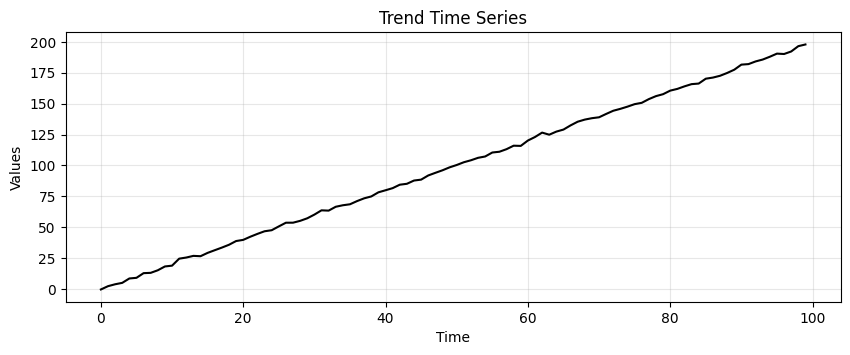

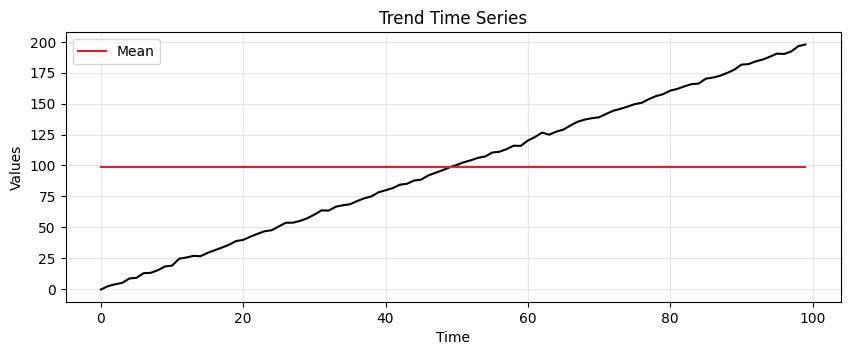

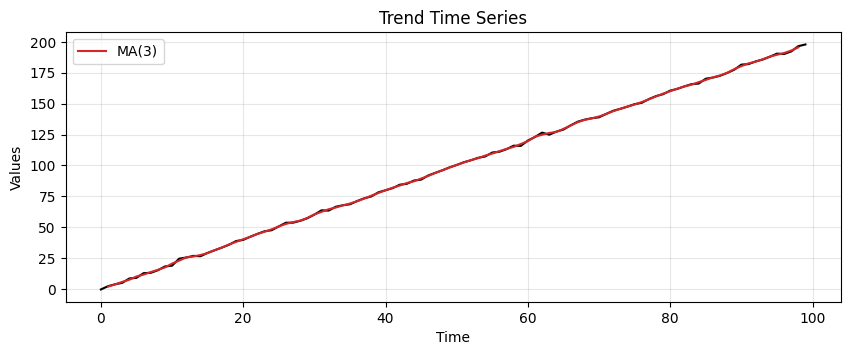

In [33]:
trend = (time * 2.0) + stationary
run_sequence_plot(time, trend, title="Trend Time Series")

trend_mean = np.mean(trend)
trend_mean_vec = np.full(shape=len(time), fill_value=trend_mean)
ax = run_sequence_plot(time, trend, title="Trend Time Series")
ax.plot(time, trend_mean_vec, "tab:red", label="Mean")
plt.legend()

trend_ma = moving_average(trend, window=3)
run_sequence_plot(time, trend, title="Trend Time Series")
plt.plot(time[1:-1], trend_ma, "tab:red", label="MA(3)")
plt.legend()

Even if it can pick up key patterns in simple time series, it has its limitations:
1. **Assigns Equal Importance**: to all values in the window, regardless of their chronological order
2. **Window Size**: requires the selection of a specific window size, which can be arbitrary and may not suit all types of data
3. **No Adjustment**: does not adjust for trend or seasonality; can lead to innacurate predictions, especially when components are non-linear

### **Weighted Moving Average**

Weighted moving average weights recent observations more than more distant ones.

$$ w_1 + w_2 + w_3 = 1 $$
$$ w_2 = (w_1)^2 $$
$$ w_3 = (w_1)^3 $$

This gives the following weights:
$$ w_1 = 0.543, w_2 = 0.294, w_3 = 0.160 $$

In [34]:
def weighted_moving_average(
        observations: np.array, 
        weights: np.array, 
        forecast: bool = False
    ):
    if len(weights) != len(observations[0:len(weights)]):
        raise ValueError("Length of weights must match the window size")
    
    # normalize weights
    weights = np.array(weights) / np.sum(weights)
    
    # initialize the result array
    result = np.empty(len(observations) - len(weights) // 2)
    result[:] = np.nan
    
    # Calculate weighted moving average
    for i in range(len(weights)//2, len(result)):
        window = observations[i-(len(weights)//2):i+len(weights)//2+1]
        result[i] = np.dot(window, weights)
    
    # Handle forecast option
    if forecast:
        result = np.insert(result, 0, np.nan*np.ones(len(weights)//2+1))
        observations = np.append(observations, np.nan*np.ones(len(weights)//2))
        return observations, result
    else:
        return result

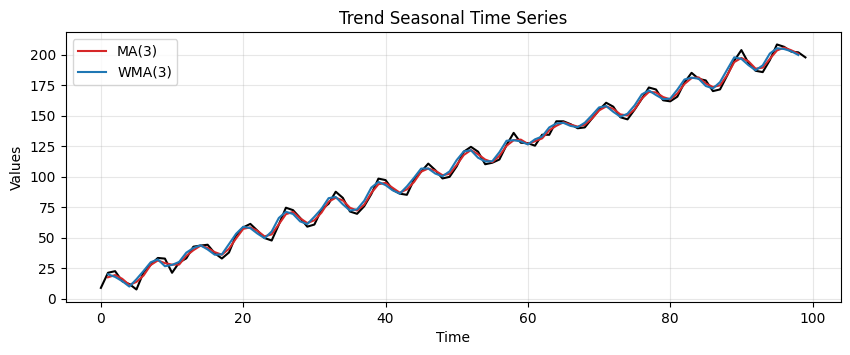

In [35]:
weights = np.array([0.160, 0.294, 0.543])
seasonality = 10 + np.sin(time) * 10 + stationary

trend_seasonality = trend + seasonality + stationary
ma_trend_seasonality = moving_average(trend_seasonality, window=3)
wma_trend_seasonality = weighted_moving_average(trend_seasonality, weights)

run_sequence_plot(time, trend_seasonality, title="Trend Seasonal Time Series")
plt.plot(time[1:-1], ma_trend_seasonality, "tab:red", label="MA(3)")
plt.plot(time[:-1], wma_trend_seasonality, "tab:blue", label="WMA(3)")
plt.legend()

### **Exponential Smoothing**

**Single Exponential Smoothing**: does not capture trend, does not capture seasonality.

$S(t) = \alpha X(t) + (1 - \alpha) S(t - 1), \text{ where}$

- $ S(t) \text{ is the smoothed value at time } t$

- $ \alpha \text{ is a smoothing constant} $

- $ X(t) \text{ is the value of the series at time } t$ 

The formula for a generic timestamp $\tau$ is:

$S(\tau) = \sum_{t=0}^{\tau} \alpha (1 - \alpha)^{\tau - t} X(t)$

**Double Exponential Smoothing**: has all the benefits of single exponential smoothing plus the ability to pickup on trend.

$S(t) = \alpha X(t) + (1 - \alpha) (S(t-1) + b(t-1)) \text{ Smoothed values of the series}$

$b(t) = \beta (S(t) - S(t-1)) + (1 - \beta) b(t-1) \text{ Estimated trend}$

$X^{~}(t+1) = S(t) + b(t) \text{ Forecasts}$

the parameters $\beta \in (0, 1)$ controls the decay of the influence of change in the trend.

**Triple Exponential Smoothing**: has all the benefits of double exponential smoothing, plus the ability to model the seasonality.


In [36]:
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing

def mse(observations: np.array, estimates: np.array):
    # check arg types
    assert type(observations) == type(np.array([])), "'observations' must be a numpy array"
    assert type(estimates) == type(np.array([])), "'estimates' must be a numpy array"
    # check length of arrays equal
    assert len(observations) == len(estimates), "Arrays must be of equal length"
    
    # calculations
    difference = observations - estimates
    sq_diff = difference ** 2
    mse = np.mean(sq_diff)
    
    return mse

In [37]:
train = trend_seasonality[:-5]
test = trend_seasonality[-5:]

##### **Single Exponential Smoothing**

In [38]:
single = SimpleExpSmoothing(train).fit(optimized=True)
single_preds = single.forecast(len(test))
single_mse = mse(test, single_preds)
print(f"MSE for Single Exponential Smoothing: {single_mse}")

MSE for Single Exponential Smoothing: 75.74930994064763


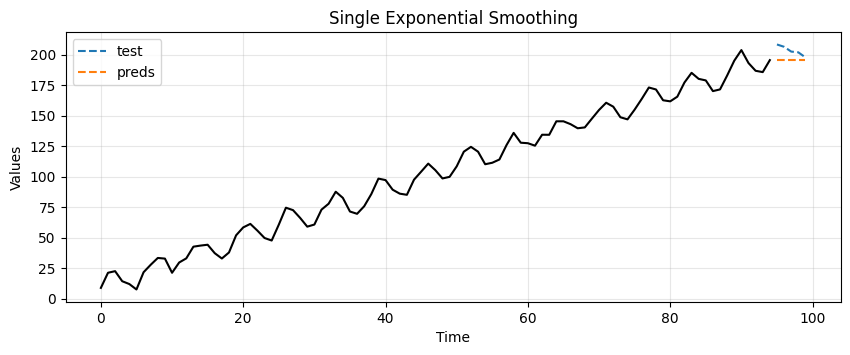

In [39]:
ax = run_sequence_plot(time[:-5], train, title="Single Exponential Smoothing")
ax.plot(time[-5:], test, color='tab:blue', linestyle="--", label="test")
ax.plot(time[-5:], single_preds, color='tab:orange', linestyle="--", label="preds")
plt.legend()

##### **Double Exponential Smoothing**

In [40]:
double = Holt(train).fit(optimized=True)
double_preds = double.forecast(len(test))
double_mse = mse(test, double_preds)
print(f"MSE: {double_mse}")

MSE: 45.22859549374311


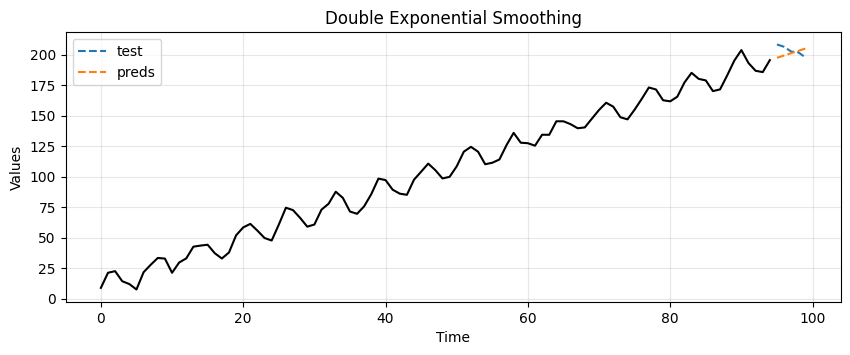

In [41]:
ax = run_sequence_plot(time[:-5], train, title="Double Exponential Smoothing")
ax.plot(time[-5:], test, color='tab:blue', linestyle="--", label="test")
ax.plot(time[-5:], double_preds, color='tab:orange', linestyle="--", label="preds")
plt.legend()

##### **Triple Exponential Smoothing**

In [42]:
triple = ExponentialSmoothing(
    train,
    trend="additive",
    seasonal="additive",
    seasonal_periods=13
).fit(optimized=True)
triple_preds = triple.forecast(len(test))
triple_mse = mse(test, triple_preds)
print("MSE: ", triple_mse)

MSE:  14.455934088549139


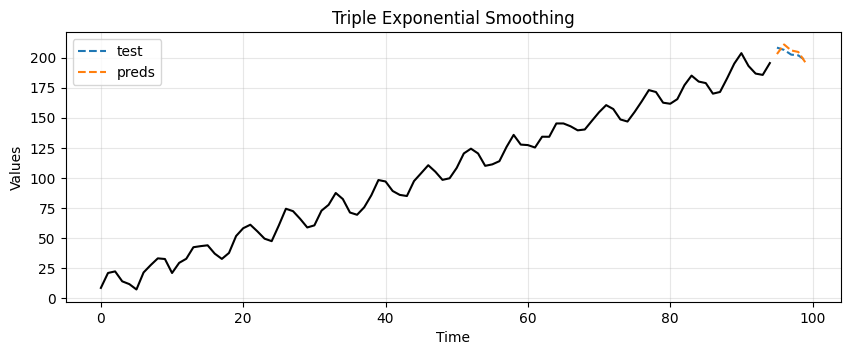

In [43]:
ax = run_sequence_plot(time[:-5], train, title=f"Triple Exponential Smoothing")
ax.plot(time[-5:], test, color='tab:blue', linestyle="--", label="test")
ax.plot(time[-5:], triple_preds, color='tab:orange', linestyle="--", label="preds")
plt.legend()

## **AR-MA**

In [44]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import ccf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.holtwinters import ExponentialSmoothing

### **Autocorrelation Function (ACF)**

The ACF measures the correlation of a time series with its own lagged values

$ACF(h) = \frac{E[(X(t) - \mu) (X(t - h) - \mu)]}{\sigma ^ 2}$

where:
- $h$ is the lag number
- $X(t)$ is the value at time $t$
- $\mu$ is the mean of the series
- $\sigma^2$ is the variance of the series

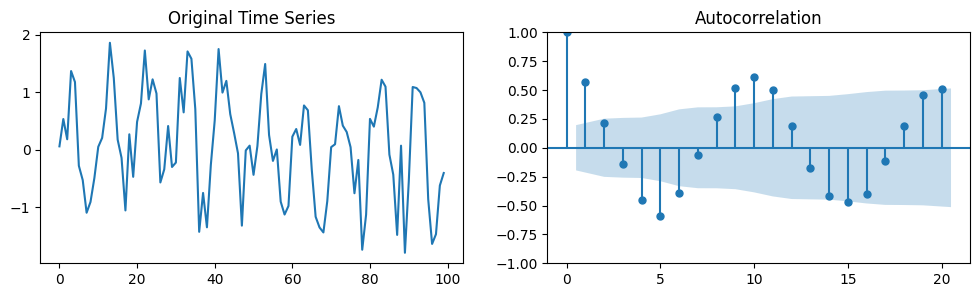

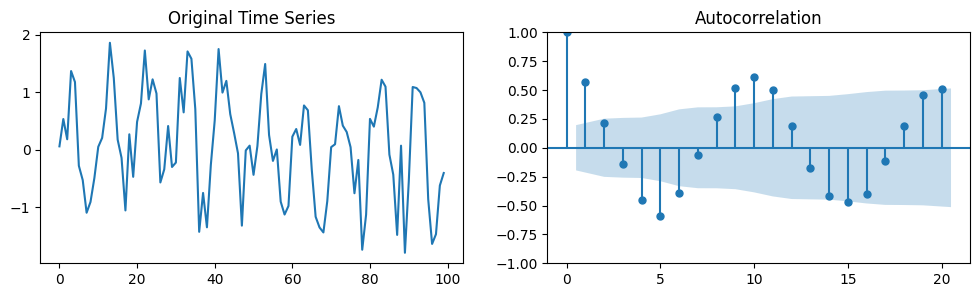

In [45]:
n = 100
ts = np.random.normal(0, 0.5, n) + np.sin(2*np.pi/10*np.arange(n))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(ts)
axes[0].set_title('Original Time Series')
plot_acf(ts, lags=20, alpha=0.05, ax=axes[1])

### **Cross Correlation Function (CCF)**

Measures the correlation between two time series at different lags:

$CCF(h) = \frac{E[(X(t) - \mu_x) (Y(t - h) - \mu_y)]}{\sigma_x \sigma_y}$

where:
- $X$ and $Y$ are two different time series
- $\mu_x$, $\mu_y$ are their means, and $\sigma_x$, $\sigma_y$ are their standard deviations.

It is usually used for searching a shorter, known feature, within a long signal.

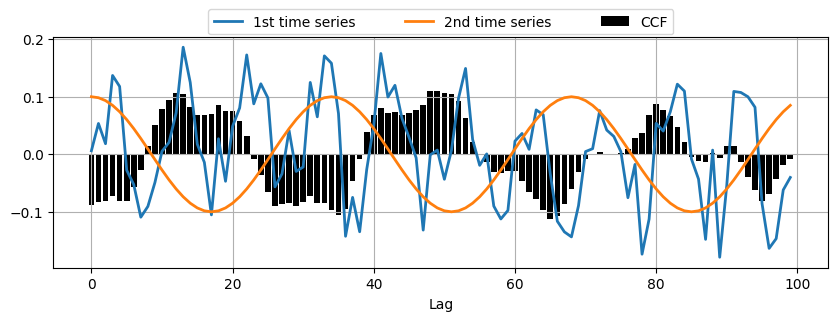

In [46]:
ts_cos = np.cos(np.pi / 17 * np.arange(n))
ccf_values = ccf(ts, ts_cos, adjusted=False)

_, ax = plt.subplots(1,1,figsize=(10,3))
ax.bar(range(len(ccf_values)), ccf_values, color='k', label='CCF')
ax.plot(ts * 0.1, linewidth=2, label='1st time series')
ax.plot(ts_cos * 0.1, linewidth=2, label='2nd time series')
plt.xlabel('Lag')
plt.legend(bbox_to_anchor=(0.2, 1.01, .6, 1.5), loc='lower center', ncol=3, mode="expand", borderaxespad=0.)
plt.grid();

One limitation of the ACF is that it measures both direct and *indirect* correlations between lags. A strong correlation at higher lags could be a result of the accumulation of correlations at shorter lags. Consider for example a random walk:

$X(t) = X(t - 1) + \epsilon_t$

The intuition tells us that only lag $h = 1$ might be important, but...

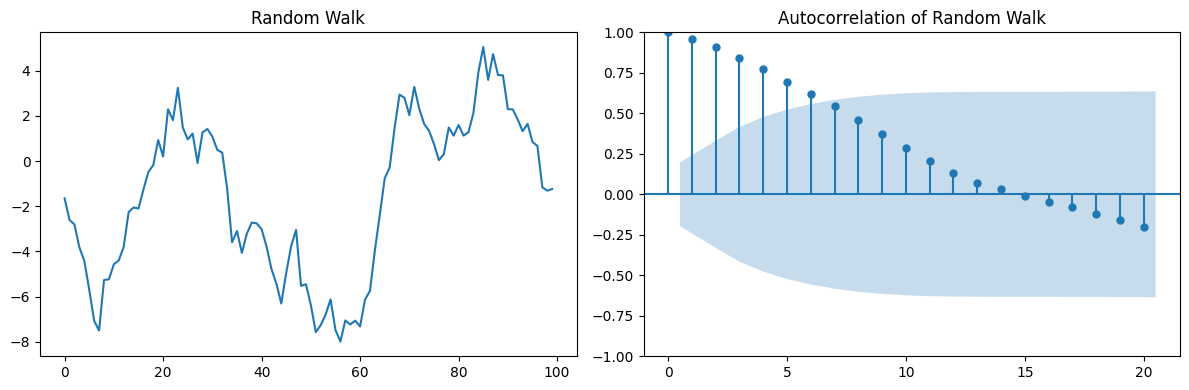

In [47]:
random_walk = np.cumsum(np.random.normal(0, 1, 100))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(random_walk)
axes[0].set_title('Random Walk')
plot_acf(random_walk, lags=20, alpha=0.05, ax=axes[1])
axes[1].set_title('Autocorrelation of Random Walk')
plt.tight_layout()

### **Partial Autocorrelation Function (PACF)**

PACF addresses this limitation of ACF by isolating the direct correlation between a time series and its lagged version. It does that by *removing the influence of correlations at shorter lags*. 

High PACF at lag $k$ indicates a strong partial correlation with the $k$-tg lag, not accounted by correlations at lower lags.

$\theta_{hh} = COR(X(t) - X^{~}(t), X(t - h) - X^{~}(t - h))$

where:
- $X^{~}(t)$ is the predicted value of $X(t)$ based on all the values up to $t - 1$
- $X^{~}(t - h)$ is the predicted value of $X(t-h)$ based on all the values up to $t - h - 1$

ACF helps in identifying the overall correlation structure and potential seasonality; PACF pinpoints the specific lags that have a significant direct impact on the current value.

<Axes: title={'center': 'Time Series with Autocorrelation'}, xlabel='Time', ylabel='Values'>

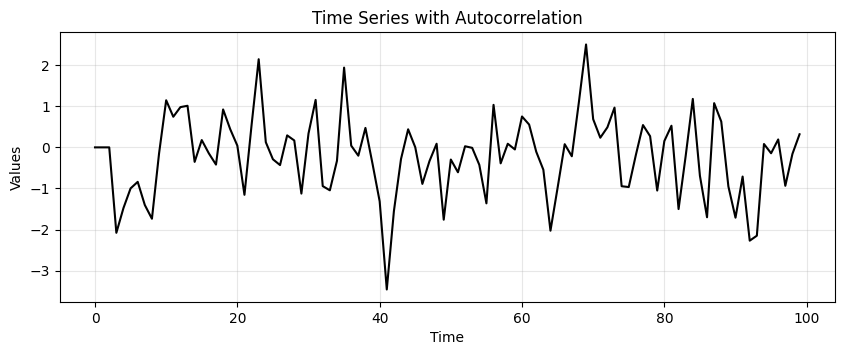

In [48]:
n = 100
ts = np.zeros(n)
alpha1, alpha2, alpha3 = 0.6, -0.3, 0.2
noise = np.random.normal(0, 1, n)

for t in range(3, n):
    ts[t] = alpha1 * ts[t - 1] + alpha2 * ts[t - 2] + alpha3 * ts[t - 3] + noise[t]

run_sequence_plot(np.arange(100), ts, title="Time Series with Autocorrelation")

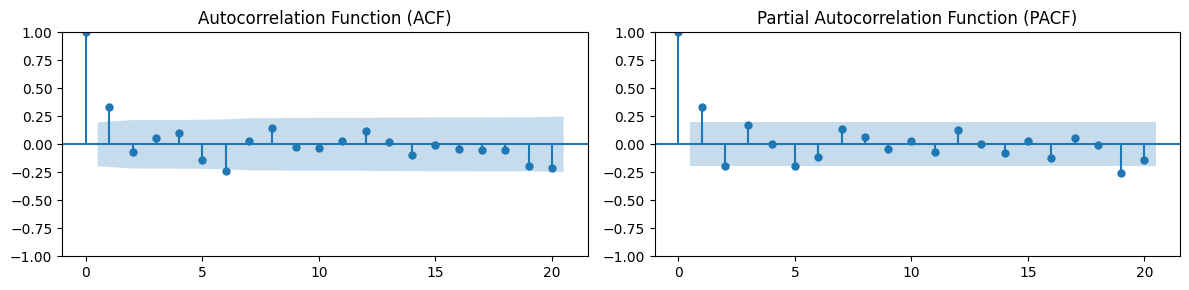

In [49]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

# Plot ACF
plot_acf(ts, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')
# Plot PACF
plot_pacf(ts, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()

### **Autoregressive (AR) Models**

An autoregressive model is a type of time series model that uses observations from previous time steps as input to a regression equation to predict the value at the next time step.

$X(t) = c + \phi_1 X(t - 1) + \phi_2 X(t - 2) + ... + \phi_p X(t - p) + \epsilon_t$

where:
- $X(t)$ time series value at time $t$
- $c$ constant term (intercept)
- $\phi_1, \phi_2, ..., \phi_p$ coefficients of the model
- $p$: order of the AR model
- $\epsilon_t$ error term (white noise) at time $t$

**Estimating AR Model Coefficients** - using various methods like the Maximum Likelihood Estimation or Least Squares Estimation; the estimated coefficients provide insights into the influence of past values on the current value in the time series. 

**Limitations:**
- require time series to be *stationary*
- higher order AR can *overfit* the training data 
- cannot deal with non-linear relationships in the data

In [50]:
ar_data = arma_generate_sample(ar=np.array([1.0, -0.5, 0.7]), ma=np.array([1]), nsample=200, scale=1, burnin=1000)

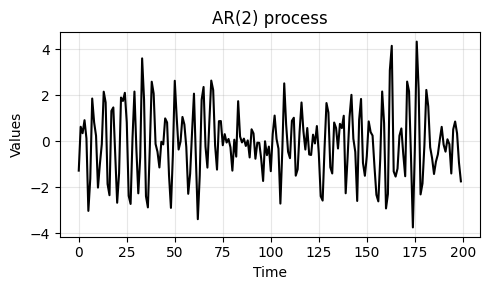

In [51]:
_, ax = plt.subplots(1, 1, figsize=(5, 3))
run_sequence_plot(np.arange(200), ar_data, ax=ax, title="AR(2) process")
plt.tight_layout()

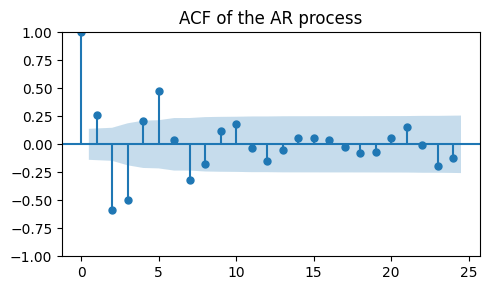

In [52]:
_, ax = plt.subplots(1, 1, figsize=(5, 3))
plot_acf(ar_data, ax=ax, title="ACF of the AR process")
plt.tight_layout();

The actual coefficients of the AR(2) process are **not** clearly visible in the ACF plot.

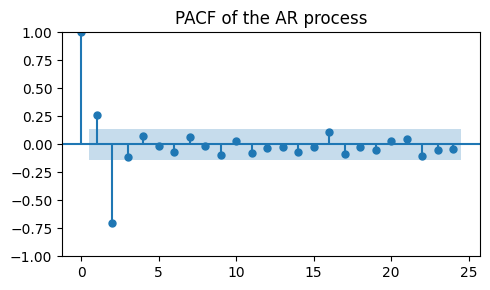

In [53]:
_, ax = plt.subplots(1, 1, figsize=(5, 3))
plot_pacf(ar_data, ax=ax, title="PACF of the AR process")
plt.tight_layout();

Besides the spike at lag 0, which is always there, we see two significant lags:
- the *positive* spike at lag 1, introduced by the *negative* coefficient -0.5
- the *negative* spike at lag 2, introduced by the *positive* coefficient 0.7

This means that the correlations in the data are explained by the previous 2 time steps.

#### **Forecasting**

**Step 1:** remove trend and seasonality; before applying an AR model is necessary to make the time series stationary.

1. Apply standard and seasonal differencing to the time series
$$ R'(t) = X(t+1) - X(t) \text{ removes trend}$$
$$ R(t) = R'(t+L) - R'(t) \text{ removes seasonality}$$
2. Estimate trend $T$ and seasonality $S$ (by using seasonal decomposition or smoothing techniques) and subtract them:
$$R(t) = X(t) - T(t) - S(t)$$

**Step 2:** apply the AR model
- identify the order of the AR model
- fit an AR model to the detrended and deseasonalized time series $R(t)$
- use the model to forecast the next values $R^{~}(t + h), h = 1, ..., H$ where $H$ is the forecast horizon

**Step 3:** reconstruct the forecast

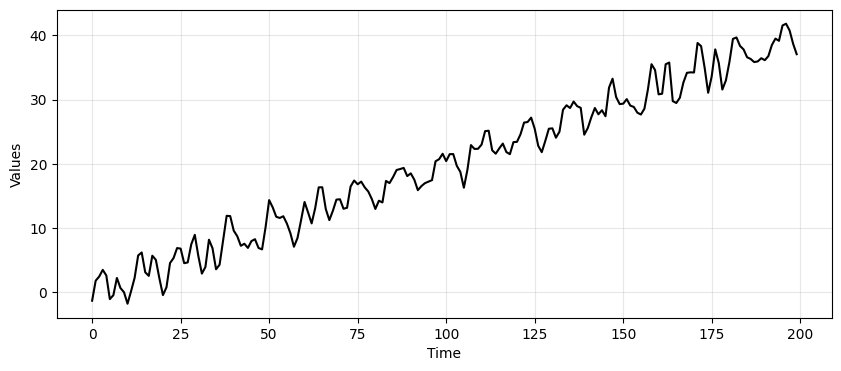

In [54]:
time = np.arange(200)
trend = time * 0.2
seasonality = 2*np.sin(2*np.pi*time/12) # Seasonality 12
time_series_ar = trend + seasonality + ar_data

_, ax = plt.subplots(1, 1, figsize=(10, 4))
run_sequence_plot(time, time_series_ar, "", ax=ax);

In [55]:
train_data_ar = time_series_ar[:164]
test_data_ar = time_series_ar[164:]

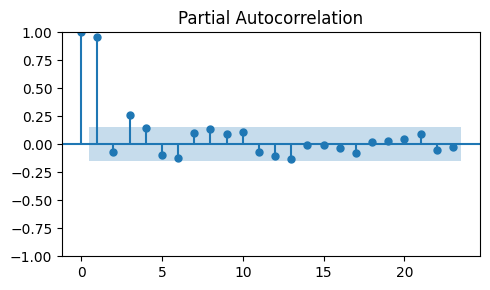

In [56]:
_, ax = plt.subplots(1, 1, figsize=(5, 3))
plot_pacf(train_data_ar, ax=ax)
plt.tight_layout();

In [57]:
_, pvalue, _, _, _, _ = adfuller(train_data_ar)

print("AR Nonstationary")
print(f"p-value: {pvalue:.3f}")
print()

diff_ar = train_data_ar[1:] - train_data_ar[:-1]

_, pvalue, _, _, _, _ = adfuller(diff_ar)

print("AR After Differencing")
print(f"p-value: {pvalue:.3f}")

AR Nonstationary
p-value: 0.902

AR After Differencing
p-value: 0.000


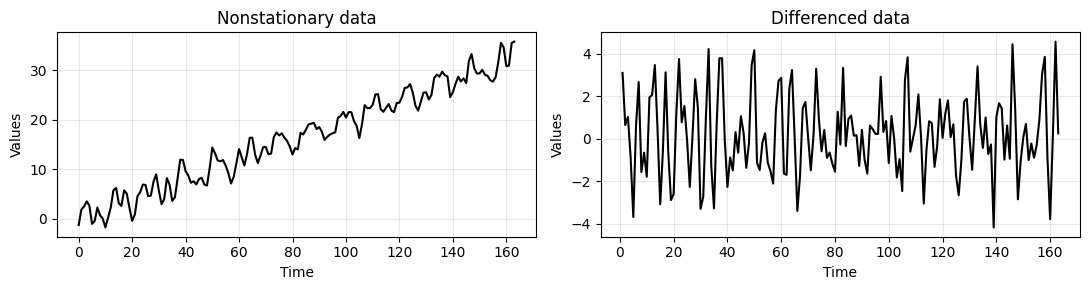

In [58]:
_, axes = plt.subplots(1,2, figsize=(11,3))
run_sequence_plot(time[:len(train_data_ar)], train_data_ar, title="Nonstationary data", ax=axes[0])
run_sequence_plot(time[1:len(train_data_ar)], diff_ar, title="Differenced data", ax=axes[1])
plt.tight_layout();

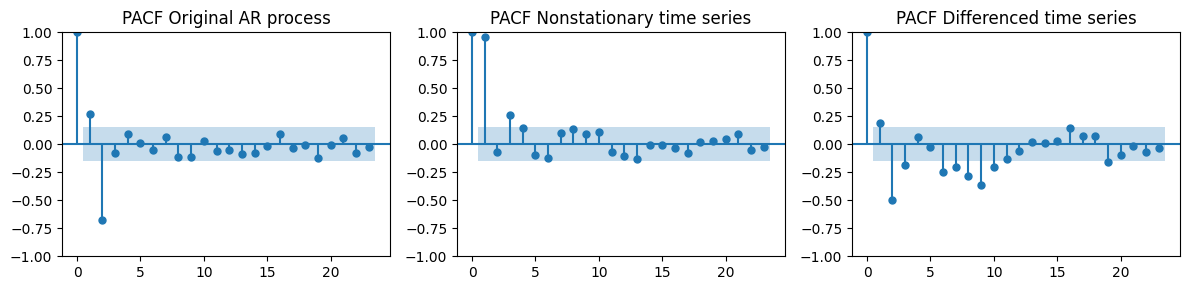

In [59]:
_, axes = plt.subplots(1, 3, figsize=(12, 3))
plot_pacf(ar_data[:len(train_data_ar)], ax=axes[0], title="PACF Original AR process")
plot_pacf(train_data_ar, ax=axes[1], title="PACF Nonstationary time series")
plot_pacf(diff_ar, ax=axes[2], title="PACF Differenced time series")
plt.tight_layout();

The proeminent negative spike at lag 2 appears both in the PACF of the original AR data and in the differenced time series. These two look way more similar than the PACF for the nonstationary data.

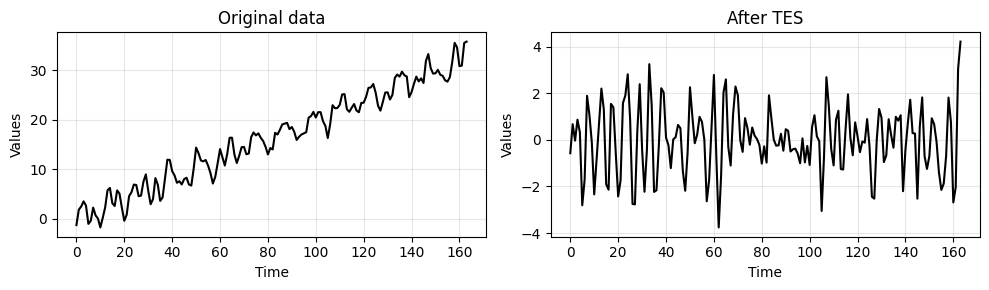

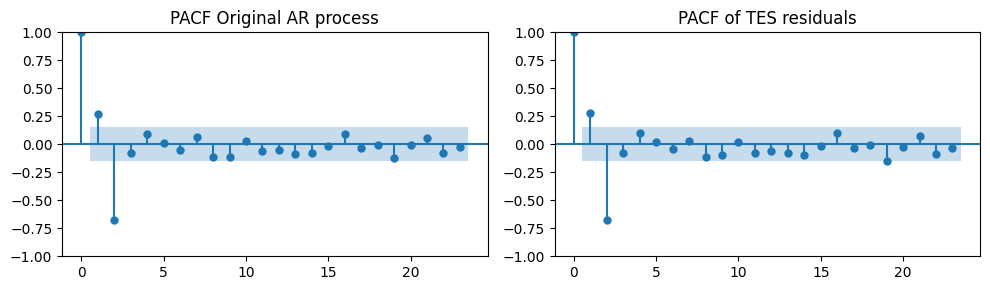

In [62]:
# as an alternative to differencing, we can estimate the trend and seasonality with triple exponential smoothing (tes)
tes = ExponentialSmoothing(
    train_data_ar,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
).fit()
trend_and_seasonality = tes.fittedvalues
tes_residuals = train_data_ar - trend_and_seasonality

# plot the original time series and the TES residuals
_, ax = plt.subplots(1, 2, figsize=(10, 3))
run_sequence_plot(time[:len(train_data_ar)], train_data_ar, title="Original data", ax=ax[0])
run_sequence_plot(time[:len(train_data_ar)], tes_residuals, title="After TES", ax=ax[1])
plt.tight_layout()

# plot the PAFC of the original AR data and the TES residuals
_, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_pacf(ar_data[:len(train_data_ar)], ax=axes[0], title="PACF Original AR process")
plot_pacf(tes_residuals, ax=axes[1], title="PACF of TES residuals")
plt.tight_layout();

In [64]:
# in this case we knew the period, but the period can be estimated with the FFT
from scipy.fft import fft

def fft_analysis(signal: np.array):
    # linear detrending
    slope, intercept = np.polyfit(np.arange(len(signal)), signal, 1)
    trend = np.arange(len(signal)) * slope + intercept 
    detrended = signal - trend 
    
    fft_values = fft(detrended)
    frequencies = np.fft.fftfreq(len(fft_values))

    # remove negative frequencies and sort
    positive_frequencies = frequencies[frequencies > 0]
    magnitudes = np.abs(fft_values)[frequencies > 0]

    # identify dominant frequency
    dominant_frequency = positive_frequencies[np.argmax(magnitudes)]
    print(f"Dominant Frequency: {dominant_frequency:.3f}")

    # convert frequency to period (e.g., days, weeks, months, etc.)
    dominant_period = 1 / dominant_frequency
    print(f"Dominant Period: {dominant_period:.2f} time units")
    
    return dominant_period, positive_frequencies, magnitudes

period, _, _ = fft_analysis(train_data_ar)
print(f"Period: {np.round(period)}")

Dominant Frequency: 0.085
Dominant Period: 11.71 time units
Period: 12.0


##### **Predictions with Differencing**

$y_t^{'} = y_t - y_{t-1}$

$y_t^{''} = y_t^{'} - y_{t-12}^{'}$

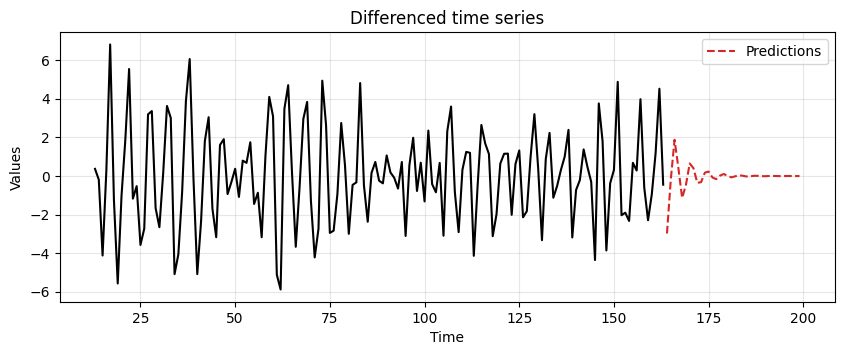

In [65]:
# remove trend
differenced_ar = train_data_ar[1:] - train_data_ar[:-1]
# remove seasonality
differenced_ar = differenced_ar[12:] - differenced_ar[:-12]

# fit the model
model = ARIMA(differenced_ar, order=(2, 0, 0))
model_fit = model.fit()
# compute predictions
differenced_preds = model_fit.forecast(steps=len(test_data_ar))

ax = run_sequence_plot(time[13:len(train_data_ar)], differenced_ar, "")
ax.plot(time[len(train_data_ar):], differenced_preds, label='Predictions', linestyle='--', color='tab:red')
plt.title('Differenced time series')
plt.legend()

To obtain the final predictions, we must first revert the seasonal differencing and the 1-st order diferencing.

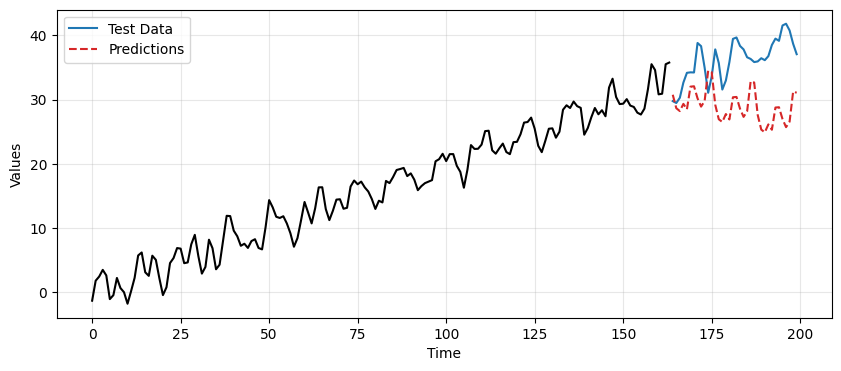

In [66]:
# reintegrate seasonal component
reintegrated_seasonal = np.zeros(len(test_data_ar))
reintegrated_seasonal[:12] = differenced_ar[-12:] + differenced_preds[:12]
for i in range(12, len(test_data_ar)):
    reintegrated_seasonal[i] = reintegrated_seasonal[i-12] + differenced_preds[i]
    
# reintegrate 1-st order differenced component
reintegrated = reintegrated_seasonal.cumsum() + train_data_ar[-1]

_, ax = plt.subplots(1, 1, figsize=(10, 4))
run_sequence_plot(time[:len(train_data_ar)], train_data_ar, "", ax=ax)
ax.plot(time[len(train_data_ar):], test_data_ar, label='Test Data', color='tab:blue')
ax.plot(time[len(train_data_ar):], reintegrated, label='Predictions', linestyle='--', color='tab:red')
plt.legend();

##### **Predictions with TES-based approach**

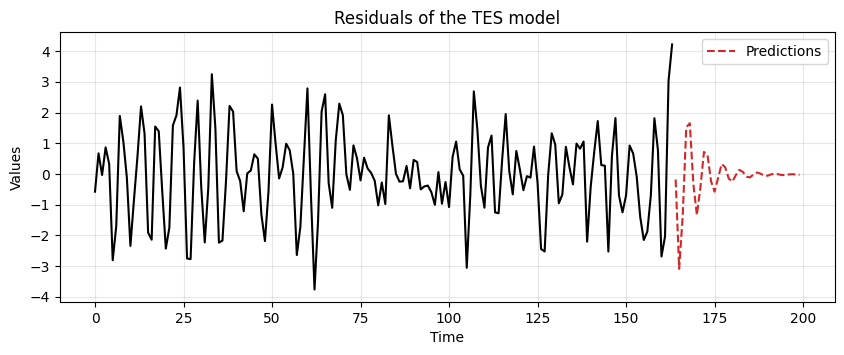

In [68]:
# fit the model
model = ARIMA(tes_residuals, order=(2, 0, 0))
model_fit = model.fit()
# compute predictions
residual_preds = model_fit.forecast(steps=len(test_data_ar))

ax = run_sequence_plot(time[:len(train_data_ar)], tes_residuals, "")
ax.plot(time[len(train_data_ar):], residual_preds, label='Predictions', linestyle='--', color='tab:red')
plt.title('Residuals of the TES model')
plt.legend()

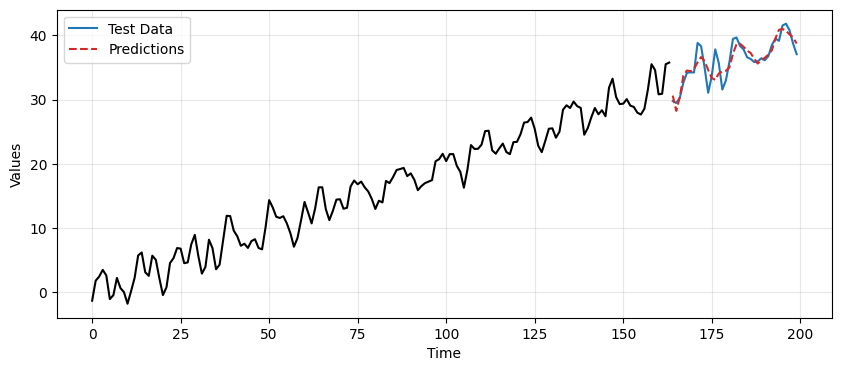

In [69]:
# add back trend and seasonality to the predictions
tes_preds = tes.forecast(len(test_data_ar))
tes_preds = tes_preds + residual_preds

_, ax = plt.subplots(1, 1, figsize=(10, 4))
run_sequence_plot(time[:len(train_data_ar)], train_data_ar, "", ax=ax)
ax.plot(time[len(train_data_ar):], test_data_ar, label='Test Data', color='tab:blue')
ax.plot(time[len(train_data_ar):], tes_preds, label='Predictions', linestyle='--', color='tab:red')
plt.legend();

##### **Differencing vs TES Predictions**

In [71]:
mse_diff = mean_squared_error(test_data_ar, reintegrated)
mse_tes = mean_squared_error(test_data_ar, tes_preds)

print(f"MSE of Differecning: {mse_diff:.4f}")
print(f"MSE of TES: {mse_tes:.4f}")

MSE of Differecning: 72.1771
MSE of TES: 2.3419


### **Moving Average (MA) Models**

The Moving Average model is a linear regression of the current value of the series against the white noise of one or more of the previous values of the series. The noise at each point is assumed to come from a normal distribution with mean 0 and constant variance.

$X(t) = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + ... + \theta_q \epsilon_{t-q}$

where:
- $X(t)$ time series value at time $t$
- $\mu$ mean of the series
- $\theta_1, \theta_2, ..., \theta_q$ coefficients of the model
- $q$ order of the MA model
- $\epsilon_t$ error term (white noise) at time $t$

MA models capture the dependency between an observation and a residual error through a moving average applied to lagged observations.

In [72]:
# ma parameters
ma = np.array([1.0, 0.7, 0.8])
ma_data = arma_generate_sample(np.array([1]), ma, nsample=len(time), scale=1, burnin=1000)

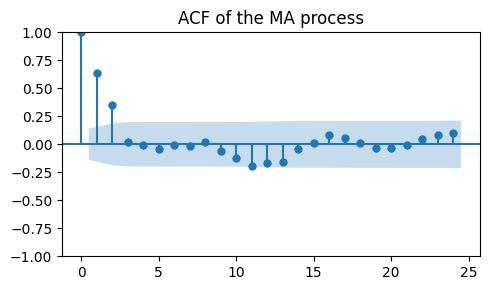

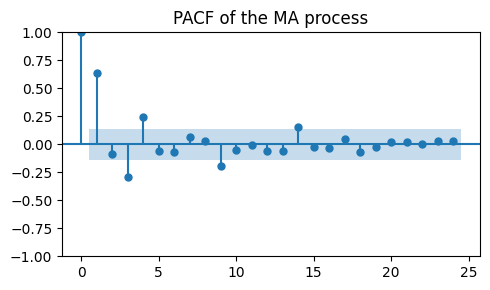

In [74]:
_, ax = plt.subplots(1, 1, figsize=(5, 3))
plot_acf(ma_data, ax=ax, title="ACF of the MA process")
plt.tight_layout();

_, ax = plt.subplots(1, 1, figsize=(5, 3))
plot_pacf(ma_data, ax=ax, title="PACF of the MA process")
plt.tight_layout();

#### **Forecasting**

<Axes: xlabel='Time', ylabel='Values'>

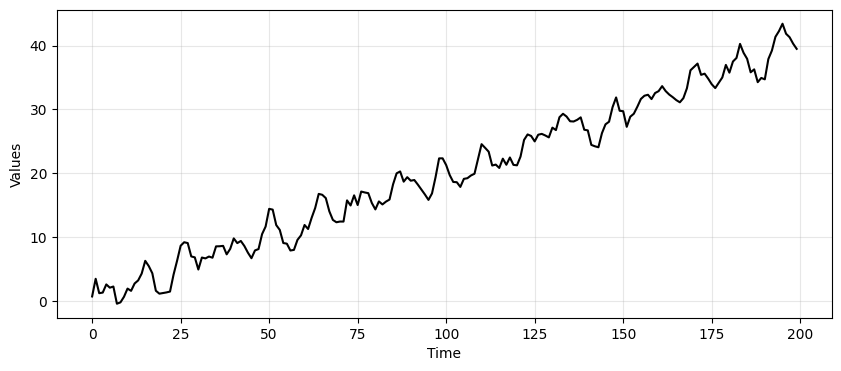

In [75]:
time_series_ma = trend + seasonality + ma_data

_, ax = plt.subplots(1, 1, figsize=(10, 4))
run_sequence_plot(time, time_series_ma, "", ax=ax)

In [76]:
train_data_ma = time_series_ma[:164]
test_data_ma = time_series_ma[164:]

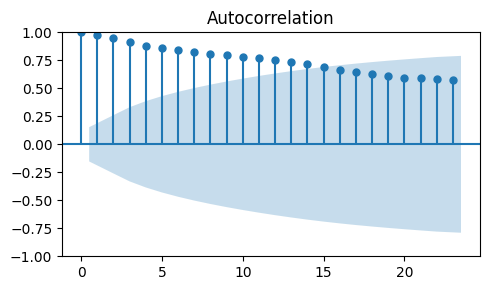

In [77]:
_, ax = plt.subplots(1, 1, figsize=(5, 3))
plot_acf(train_data_ma, ax=ax)
plt.tight_layout();

##### **Stationarity through Differencing**

In [78]:
diff_ma = train_data_ma[1:] - train_data_ma[:-1]

_, pvalue_ts, _, _, _, _ = adfuller(train_data_ma)
_, pvalue_diff, _, _, _, _ = adfuller(diff_ma)
print(f"p-value (original MA): {pvalue_ts:.3f}")
print(f"p-value (differenced MA): {pvalue_diff:.3f}")

p-value (original MA): 0.957
p-value (differenced MA): 0.000


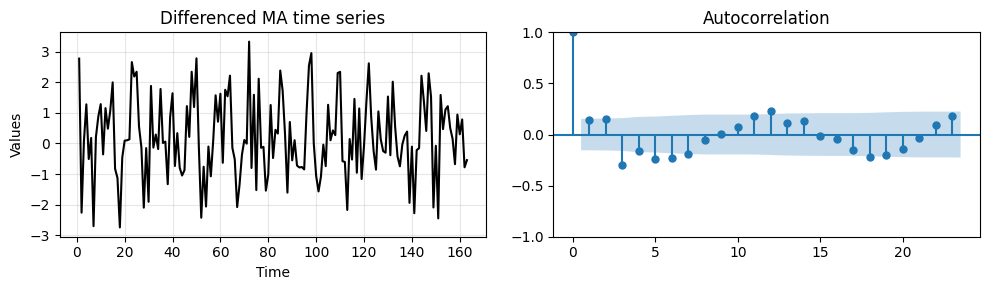

In [79]:
_, axes = plt.subplots(1,2, figsize=(10, 3))
run_sequence_plot(time[1:len(train_data_ma)], diff_ma, "Differenced MA time series", ax=axes[0])
plot_acf(diff_ma, ax=axes[1])
plt.tight_layout();

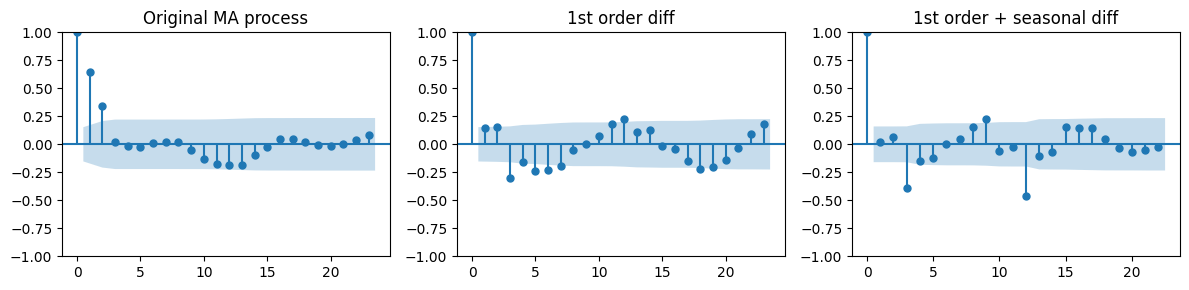

In [80]:
diff_diff_ma = diff_ma[12:] - diff_ma[:-12]

_, axes = plt.subplots(1,3, figsize=(12, 3))
plot_acf(ma_data[:len(train_data_ma)], ax=axes[0], title="Original MA process")
plot_acf(diff_ma, ax=axes[1], title="1st order diff")
plot_acf(diff_diff_ma, ax=axes[2], title="1st order + seasonal diff")
plt.tight_layout();

It is unclear which MA model to use from the analysis of the ACF plots:
- the ACF after 1st order differencing suggest using order $q=1$ or $q=2$
- the ACF obtained after seasonal differencing suggest order $q=3$, but we suspect **overdifferencing**

##### **Stationarity with TES**

In the following the same procedure to estimate trend and seasonality with TES is repeated. Since the MA process is more *noisy* that the AR process, we increase the level of smoothing by setting $\alpha = 0.01$.

Dominant Frequency: 0.085
Dominant Period: 11.76 time units


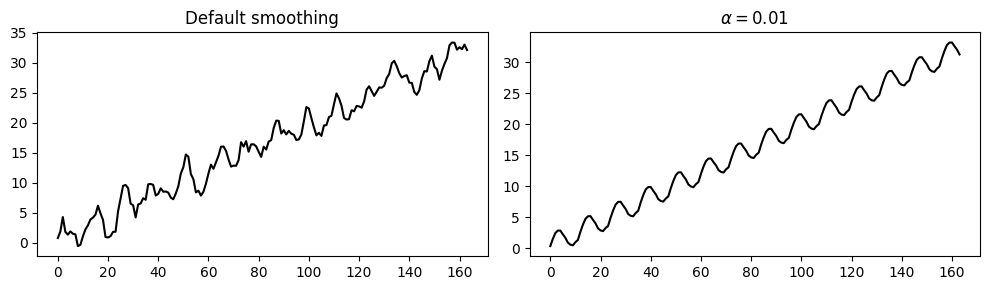

In [81]:
# compute the periodicity of the time series using the FFT
period, _, _ = fft_analysis(time_series_ma)
period = np.round(period).astype(int)

# fit the TES with and without smoothing level
tes_ma_default = ExponentialSmoothing(train_data_ma, trend='add', seasonal='add', seasonal_periods=period).fit(smoothing_level=None)
tes_ma = ExponentialSmoothing(train_data_ma, trend='add', seasonal='add', seasonal_periods=period).fit(smoothing_level=0.01)
# extract trend and seasonality
trend_and_seasonality_default = tes_ma_default.fittedvalues
trend_and_seasonality = tes_ma.fittedvalues

_, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(trend_and_seasonality_default, 'k')
axes[0].set_title('Default smoothing')
axes[1].plot(trend_and_seasonality, 'k')
axes[1].set_title('$\\alpha=0.01$')
plt.tight_layout();

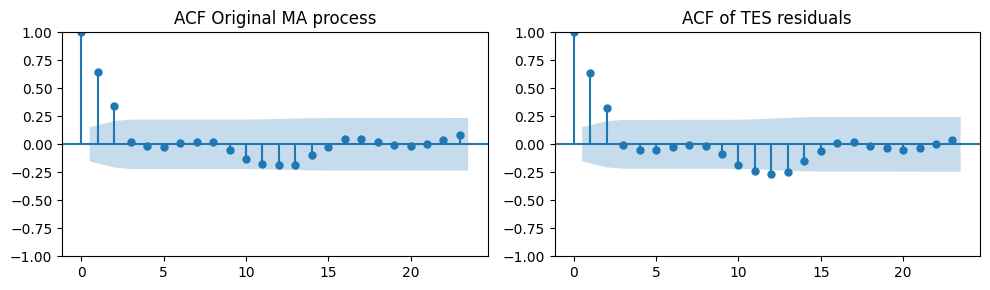

In [83]:
tes_resid_ma = train_data_ma - trend_and_seasonality

_, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(ma_data[:len(train_data_ma)], ax=axes[0], title="ACF Original MA process")
plot_acf(tes_resid_ma, ax=axes[1], title="ACF of TES residuals")
plt.tight_layout()

##### **Predictions with Differencing**

c:\Users\Vlad Wero\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


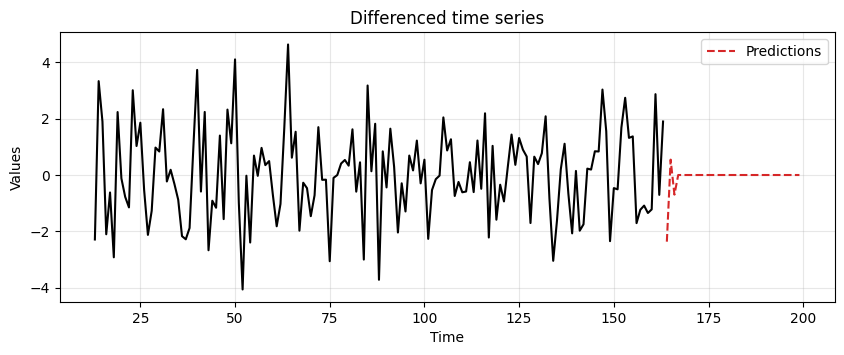

In [84]:
# fit the model
model = ARIMA(diff_diff_ma, order=(0, 0, 3))
model_fit = model.fit()
# compute predictions
diff_preds = model_fit.forecast(steps=len(test_data_ma))

ax = run_sequence_plot(time[13:len(train_data_ma)], diff_diff_ma, "")
ax.plot(time[len(train_data_ma):], diff_preds, label='Predictions', linestyle='--', color='tab:red')
plt.title('Differenced time series')
plt.legend()

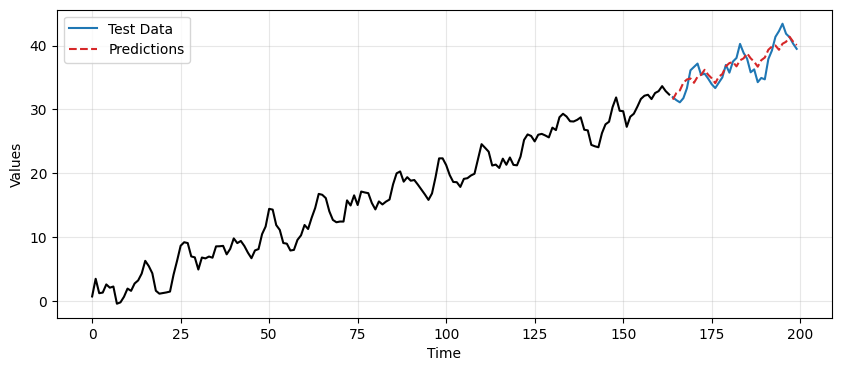

In [85]:
# reintegrating the seasonal differencing
reintegrated_seasonal = np.zeros(len(test_data_ma))
reintegrated_seasonal[:12] = diff_ma[-12:] + diff_preds[:12]
for i in range(12, len(test_data_ma)):
    reintegrated_seasonal[i] = reintegrated_seasonal[i-12] + diff_preds[i]

# reintegrating 1st order differencing
reintegrated = reintegrated_seasonal.cumsum() + train_data_ma[-1]

_, ax = plt.subplots(1, 1, figsize=(10, 4))
run_sequence_plot(time[:len(train_data_ma)], train_data_ma, "", ax=ax)
ax.plot(time[len(train_data_ma):], test_data_ma, label='Test Data', color='tab:blue')
ax.plot(time[len(train_data_ma):], reintegrated, label='Predictions', linestyle='--', color='tab:red')
plt.legend();

##### **Predicting with TES**

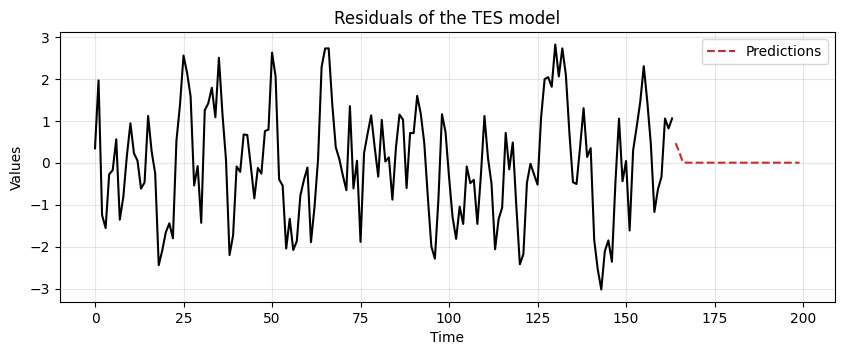

In [87]:
# fit the model
model = ARIMA(tes_resid_ma, order=(0, 0, 3))
model_fit = model.fit()
# compute the predictions
residual_preds = model_fit.forecast(steps=len(test_data_ma))

ax = run_sequence_plot(time[:len(train_data_ma)], tes_resid_ma, "")
ax.plot(time[len(train_data_ma):], residual_preds, label='Predictions', linestyle='--', color='tab:red')
plt.title('Residuals of the TES model')
plt.legend();

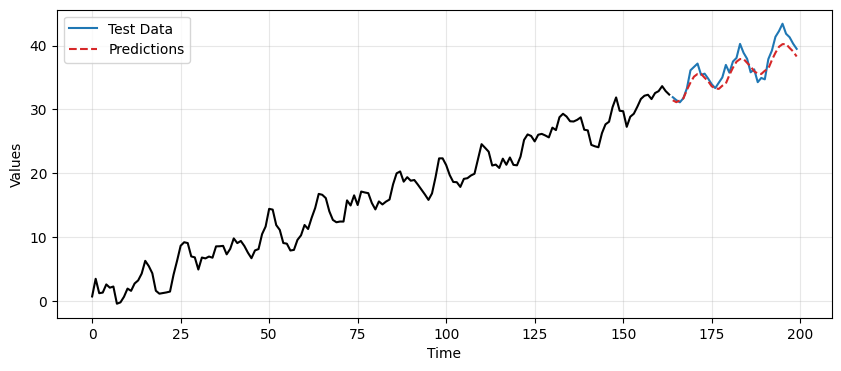

In [88]:
# add back trend and seasonality to the predictions
tes_preds = tes_ma.forecast(len(test_data_ma))
tes_preds = tes_preds + residual_preds

_, ax = plt.subplots(1, 1, figsize=(10, 4))
run_sequence_plot(time[:len(train_data_ma)], train_data_ma, "", ax=ax)
ax.plot(time[len(train_data_ma):], test_data_ma, label='Test Data', color='tab:blue')
ax.plot(time[len(train_data_ma):], tes_preds, label='Predictions', linestyle='--', color='tab:red')
plt.legend();

##### **Differencing vs TES Predictions**

In [89]:
mse_differencing = mean_squared_error(test_data_ma, reintegrated)
mse_tes = mean_squared_error(test_data_ma, tes_preds)

print(f"MSE of differencing: {mse_differencing:.2f}")
print(f"MSE of TES: {mse_tes:.2f}")

MSE of differencing: 2.68
MSE of TES: 1.94


### **AR vs MA Models**

**AR Models:**
- depend on past values of the series
- suitable when past values have a direct influence on future values and for slowly changing time series

**MA Models:**
- depend on past forecast errors
- useful when the series is better explained by shocks or random disturbances (i.e., time series with sudden changes)

## **ARMA, ARIMA**

**ARMA** = Autoregressive Moving Average 

**ARIMA** = Autoregressive Integrated Moving Average

In [122]:
import statsmodels as ss
from statsmodels.graphics.tsaplots import month_plot
from scipy import stats
from statsmodels.tsa.statespace.tools import diff

### **ARMA**

#### **Dataset**

We'll have a look at the monthly average temperature between 1907-1972.

In [90]:
# load data and convert to datetime
monthly_temp = pd.read_csv('https://zenodo.org/records/10951538/files/arima_temp.csv?download=1', 
    skipfooter=2, 
    header=0, 
    index_col=0, 
    names=['month', 'temp'],
    engine='python'
)
monthly_temp.index = pd.to_datetime(monthly_temp.index)

In [91]:
monthly_temp.head()

,temp
month,
1907-01-01,33.3
1907-02-01,46.0
1907-03-01,43.0
1907-04-01,55.0
1907-05-01,51.8


In [92]:
monthly_temp.describe()

,temp
count,792.000000
mean,53.553662
std,15.815452
min,11.200000
25%,39.675000
50%,52.150000
75%,67.200000
max,82.400000


<Axes: title={'center': 'Monthly Temperature'}, xlabel='month'>

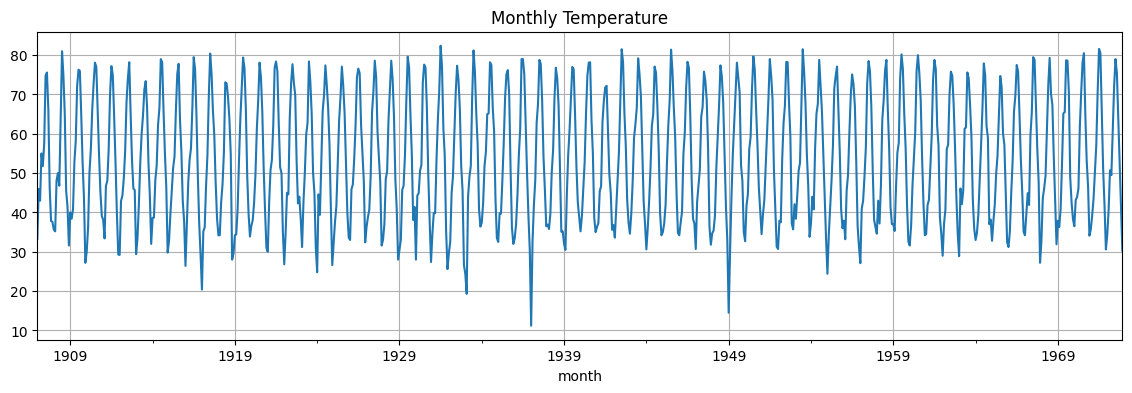

In [93]:
monthly_temp['temp'].plot(grid=True, figsize=(14, 4), title='Monthly Temperature')

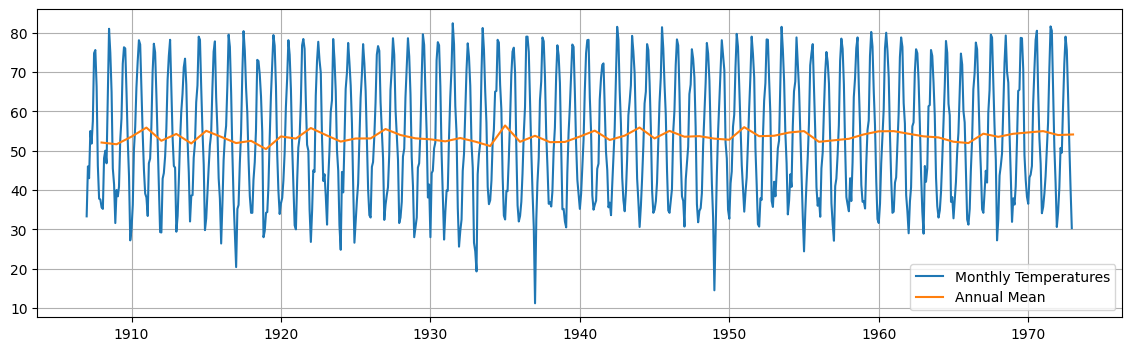

In [94]:
# compute annual mean
annual_temp = monthly_temp.resample('YE').mean()
annual_temp.index.name = 'year'

plt.figure(figsize=(14, 4))
plt.plot(monthly_temp, label="Monthly Temperatures")
plt.plot(annual_temp, label="Annual Mean")
plt.grid(); plt.legend()

This gives us an indication that the mean is rather constant over the years. 

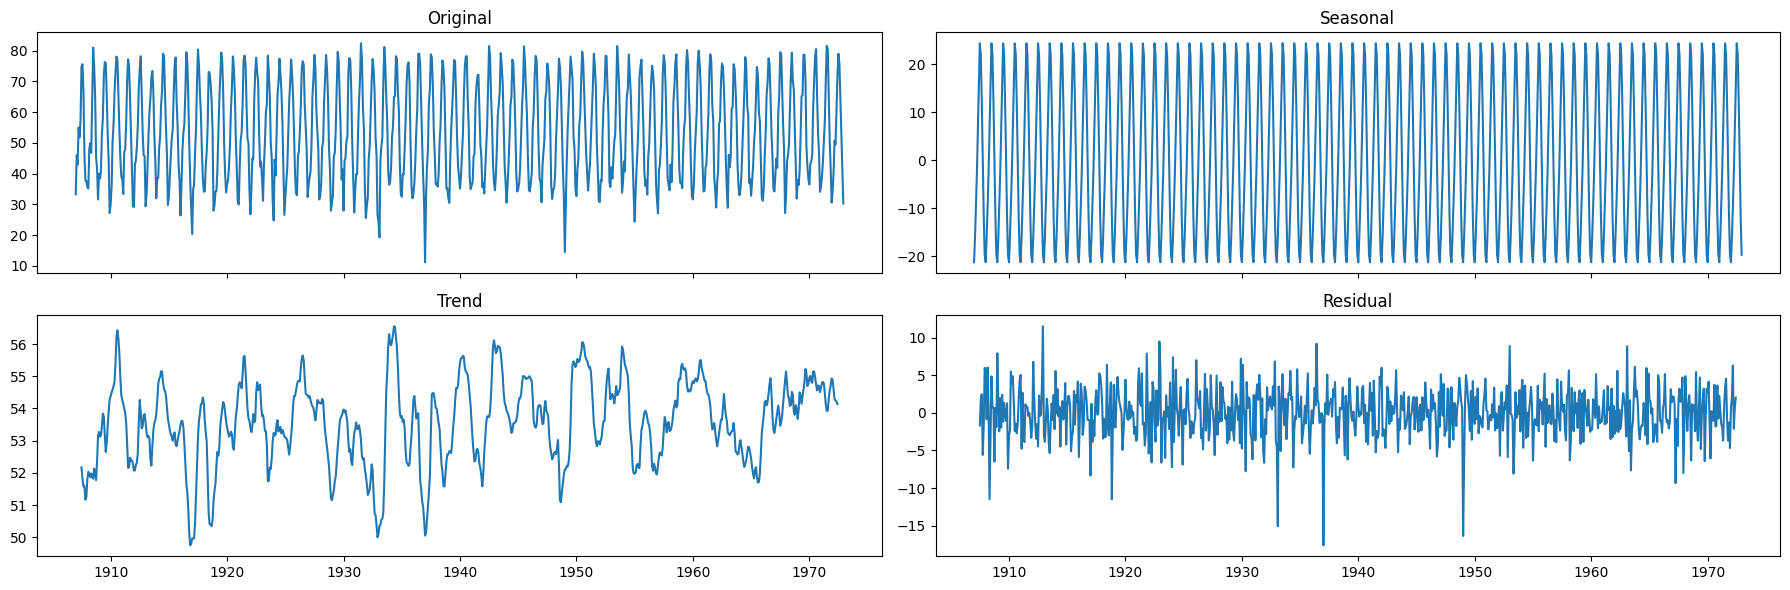

In [95]:
decomposition = seasonal_decompose(x=monthly_temp['temp'], model='additive', period=12)
seasonal, trend, residuals = decomposition.seasonal, decomposition.trend, decomposition.resid

fig, axs = plt.subplots(2,2, sharex=True, figsize=(18,6))
axs[0,0].plot(monthly_temp['temp'])
axs[0,0].set_title('Original')
axs[0,1].plot(seasonal)
axs[0,1].set_title('Seasonal')
axs[1,0].plot(trend)
axs[1,0].set_title('Trend')
axs[1,1].plot(residuals)
axs[1,1].set_title('Residual')
plt.tight_layout()

#### **Modeling Stages**

There are *three* stages in building an ARMA model:
1. Model *identification*: finding the orders $p$ and $q$ of AR and MA components; before this, it needs to be determined in the time series is stationary and if it contains a seasonal component
2. Model *estimation*
3. Model *evaluation*

#### **Determine Seasonality**

It can be determined if seasonality is present by using the following tools:
- autocorrelation plot
- seasonal subseries plot
- fourier transform

In [96]:
# generate synthetic time series data
dates = pd.date_range(start='2010-01-01', periods=60, freq='ME')  # monthly data for 5 years
seas = 12
data = (np.sin(np.arange(60)*2*np.pi/seas) + 
        np.random.normal(loc=0, scale=0.2, size=60))  # seasonal data with noise
series = pd.Series(data, index=dates)

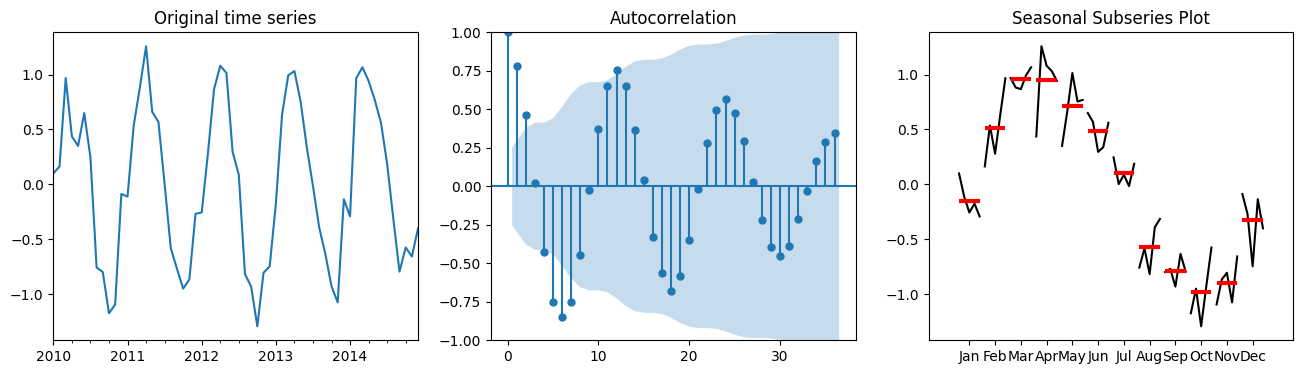

In [98]:
fig, axes = plt.subplots(1,3,figsize=(16,4))
series.plot(ax=axes[0], title="Original time series")

# ACF plot
plot_acf(series, lags=36, ax=axes[1]);

# convert series to a DataFrame and add a column for the month
df = series.to_frame(name='Value')
df['Month'] = df.index.month

# seasonal subseries plot
month_plot(df['Value'], ax=axes[2]); axes[2].set_title("Seasonal Subseries Plot");

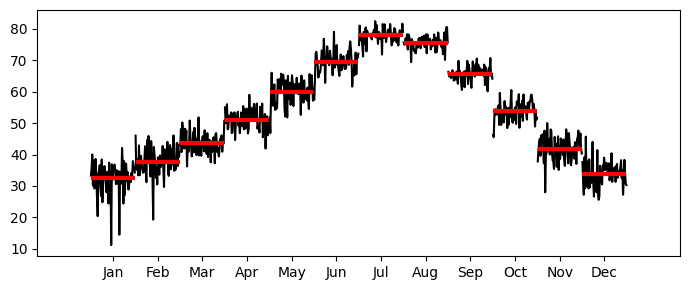

In [99]:
_, ax = plt.subplots(1,1, figsize=(7,3))
month_plot(monthly_temp, ax=ax)
plt.tight_layout();

In [100]:
dominant_period, _, _ = fft_analysis(monthly_temp['temp'].values)
print(f"Dominant period: {np.round(dominant_period)}")

Dominant Frequency: 0.083
Dominant Period: 12.00 time units
Dominant period: 12.0


In [101]:
# remove seasonality
monthly_temp['seasonally_differenced'] = monthly_temp['temp'].diff(12)
monthly_temp_clean = monthly_temp.dropna()
monthly_temp_clean

,temp,seasonally_differenced
month,,
1908-01-01,35.6,2.3
1908-02-01,35.2,-10.8
1908-03-01,48.1,5.1
1908-04-01,50.0,-5.0
1908-05-01,46.8,-5.0
...,...,...
1972-08-01,75.6,-4.9
1972-09-01,64.1,-1.7
1972-10-01,51.7,0.6


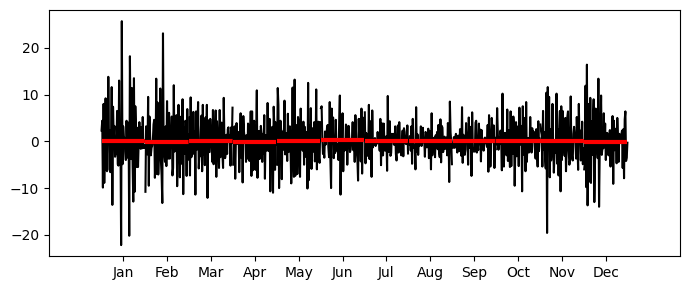

In [102]:
_, ax = plt.subplots(1,1, figsize=(7,3))
month_plot(monthly_temp_clean['seasonally_differenced'], ax=ax)
plt.tight_layout();

#### **Identifying $p$ and $q$**

**AR(p)**: plot 95% confidence interval on the PACF and choose lag $p$ such that the partial autocorrelation becomes insignificant for $p + 1$ and beyond; AR processes propagates shocks infinitely; will exhibit exponential decay in ACF and cut-off in PACF.

**MA(q)**: plot 95% confidence interval on the ACF and choose lag $q$ such that ACF becomes statistically zero for $q + 1$ and beyond; MA models do not propagate shocks infinitely, they die after $q$ lags; will exhibit exponential decay in PACF and cut-off in ACF.

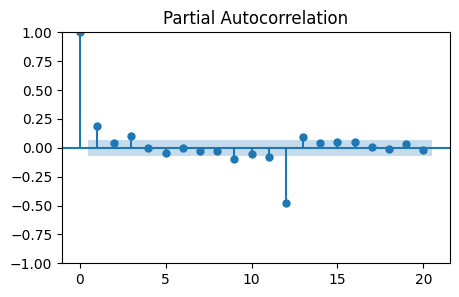

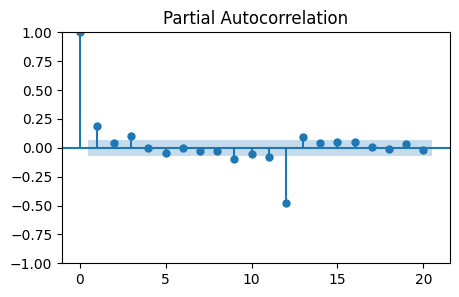

In [105]:
_, ax = plt.subplots(1, 1, figsize=(5, 3))
plot_pacf(monthly_temp_clean['seasonally_differenced'], lags=20, ax=ax) 

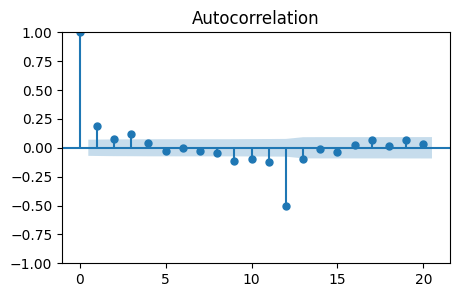

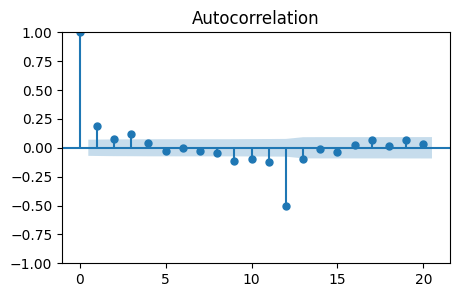

In [106]:
_, ax = plt.subplots(1, 1, figsize=(5, 3))
plot_acf(monthly_temp_clean['seasonally_differenced'], lags=20, ax=ax)

#### **Model Estimation**

Once the orders $p$ and $q$ are identified is necessary to estimate parameters $ \phi_1, \phi_2, ..., \phi_p $ of the AR model and parameters $ \theta_1, \theta_2, ..., \theta_q $ of the MA part. Estimating the parameters of an ARMA model is a nonlinear problem.

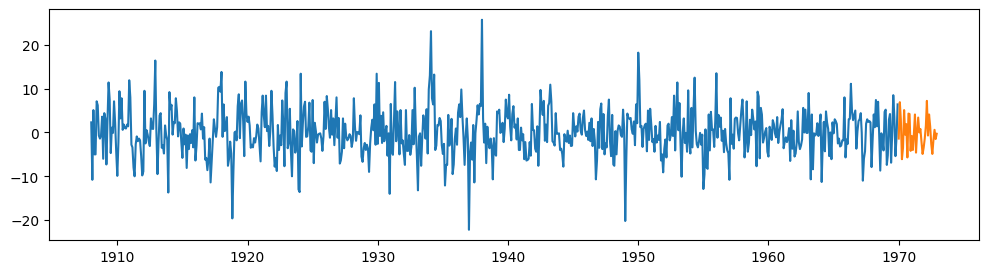

In [107]:
train = monthly_temp_clean['seasonally_differenced'][:-36]
test = monthly_temp_clean['seasonally_differenced'][-36:]

plt.figure(figsize=(12, 3))
plt.plot(train)
plt.plot(test)

In [108]:
p = 3
q = 3
model = ARIMA(train, order=(p, 0, q))
fit_model = model.fit()

print(fit_model.summary())

c:\Users\Vlad Wero\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Vlad Wero\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Vlad Wero\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                  
Dep. Variable:     seasonally_differenced   No. Observations:                  744
Model:                     ARIMA(3, 0, 3)   Log Likelihood               -2248.183
Date:                    Mon, 30 Mar 2026   AIC                           4512.365
Time:                            16:36:40   BIC                           4549.261
Sample:                        01-01-1908   HQIC                          4526.587
                             - 12-01-1969                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0647      0.248      0.261      0.794      -0.421       0.550
ar.L1         -0.0717      0.140     -0.511      0.609      -0.347       0.203
ar.L2         -0.824

c:\Users\Vlad Wero\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


#### **Model Validation**

How do we know if our ARMA model is good enough? We can check the residuals, i.e., what the model was not able to fit. The residuals should approximate a Gaussian distribution.

Text(0.5, 1.0, 'Residuals SARIMAX')

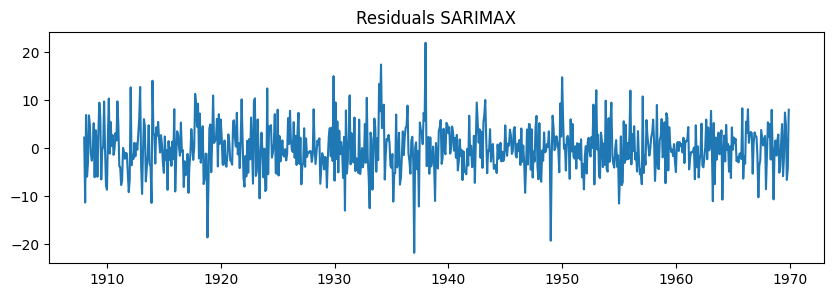

In [109]:
residuals = fit_model.resid

plt.figure(figsize=(10, 3))
plt.plot(residuals)
plt.title("Residuals SARIMAX")

To test if the residuals look like noise, we will use both *visual* inspection, as well as *statistical tests*.

*Visual inspection*:
- ACF plot
- histogram
- QQ plot

*Statistical tests*:
- normality
- autocorrelation
- heteroskedasticity

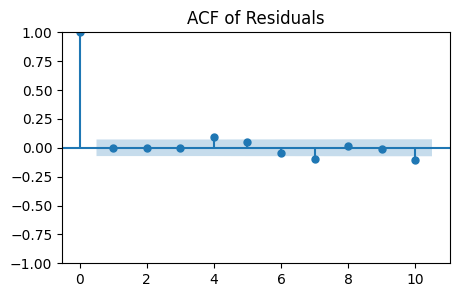

In [110]:
_, ax = plt.subplots(1, 1, figsize=(5, 3))
plot_acf(residuals, lags=10, ax=ax)
plt.title('ACF of Residuals');

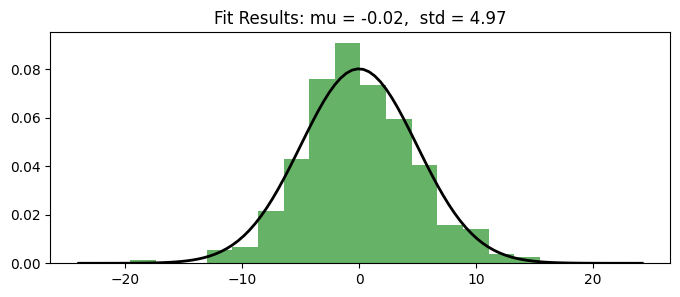

In [112]:
# NOTE: White Noise should ideally follow a normal distribution
plt.figure(figsize=(8,3))
plt.hist(residuals, bins=20, density=True, alpha=0.6, color='g') # Histogram

# add the normal distribution curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, np.mean(residuals), np.std(residuals))
plt.plot(x, p, 'k', linewidth=2)
title = "Fit Results: mu = %.2f,  std = %.2f" % (np.mean(residuals), np.std(residuals))
plt.title(title);

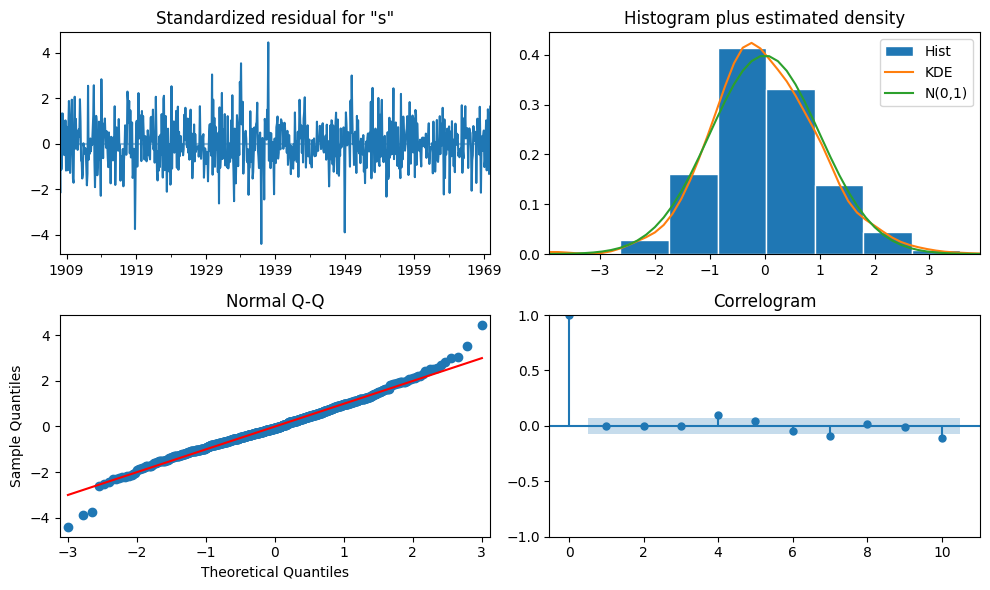

In [113]:
fit_model.plot_diagnostics(figsize=(10, 6))
plt.tight_layout()

**Statistical Tests**

**Normality**: Jarque-Bera and Shapiro-Walk tests - $H_0$ = the residuals are normally distributed

**Autocorrelation**: Ljung-Box and Durbin Watson test

**Heteroskedasticity Test**: test for change in variance between residuals; $H_0$ indicates different things based on the alternative $H_A$:
- $H_A$: increasing; $H_0$: the variance is not increasing throughout the series
- $H_B$: decreasing; $H_0$: the variance is not decreasing throughtout the series
- $H_A$: two-sided (default); $H_0$: the variance does not increase nor decrease throughout the series

In [115]:
norm_val, norm_p, skew, kurtosis = fit_model.test_normality('jarquebera')[0]
print('Normality (Jarque-Bera) p-value:{:.3f}'.format(norm_p))

shapiro_test = stats.shapiro(residuals)
print(f'Normality (Shapiro-Wilk) p-value: {shapiro_test.pvalue:.3f}')

statistic, pval = fit_model.test_serial_correlation(method='ljungbox', lags=10)[0]
print(f'Ljung-Box p-value: {pval.mean():.3f}') 

durbin_watson = ss.stats.stattools.durbin_watson(
    fit_model.filter_results.standardized_forecasts_error[0, fit_model.loglikelihood_burn:])
print('Durbin-Watson: d={:.2f}'.format(durbin_watson))

_, pval = fit_model.test_heteroskedasticity('breakvar', alternative='increasing')[0]
print(f'Heteroskedasticity Increasing - pvalue:{pval:.3f}')
_, pval = fit_model.test_heteroskedasticity('breakvar', alternative='decreasing')[0]
print(f'Heteroskedasticity Decreasing - pvalue:{pval:.3f}')
_, pval = fit_model.test_heteroskedasticity('breakvar', alternative='two-sided')[0]
print(f'Heteroskedasticity Two-sided - pvalue:{pval:.3f}')

Normality (Jarque-Bera) p-value:0.000
Normality (Shapiro-Wilk) p-value: 0.000
Ljung-Box p-value: 0.344
Durbin-Watson: d=1.99
Heteroskedasticity Increasing - pvalue:0.982
Heteroskedasticity Decreasing - pvalue:0.018
Heteroskedasticity Two-sided - pvalue:0.037


Independence:
- ✅ ACF plot.
- ✅ Ljung-Box test.
- ✅ Durbin Watson test.

Normality:
- ✅ Histogram/Density plot.
- 🤔 QQ-plot
- ❌ Jarque-Bera (reliable for large sample size).
- ❌ Shapiro-Wilk (reliable for large sample size).

Heteroskedasticity:
- ❌ Heteroskedasticity test.

#### **Predictions**

Once the model is fit, we can use it to predict the test data. The predictions come in the form of a *distribution*. In other words, ARMA performs a *probabilistic forecasting*. The mean (mode) of this distribution correspond to the most likely value and correspond to our forecast.

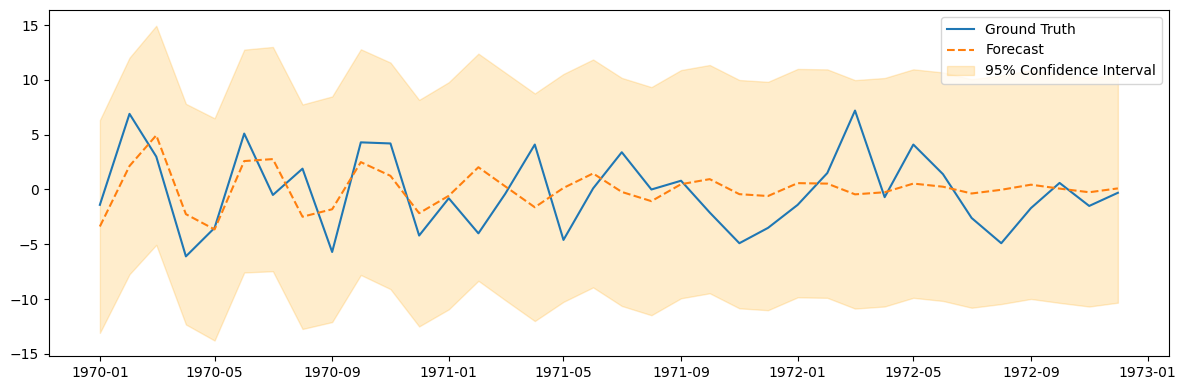

In [116]:
pred_summary = fit_model.get_prediction(test.index[0], test.index[-1]).summary_frame()

plt.figure(figsize=(12, 4))
plt.plot(test.index, test, label='Ground Truth')
plt.plot(test.index, pred_summary['mean'], label='Forecast', linestyle='--')
plt.fill_between(test.index, pred_summary['mean_ci_lower'], pred_summary['mean_ci_upper'], 
                 color='orange', alpha=0.2, label='95% Confidence Interval')
plt.legend()
plt.tight_layout();

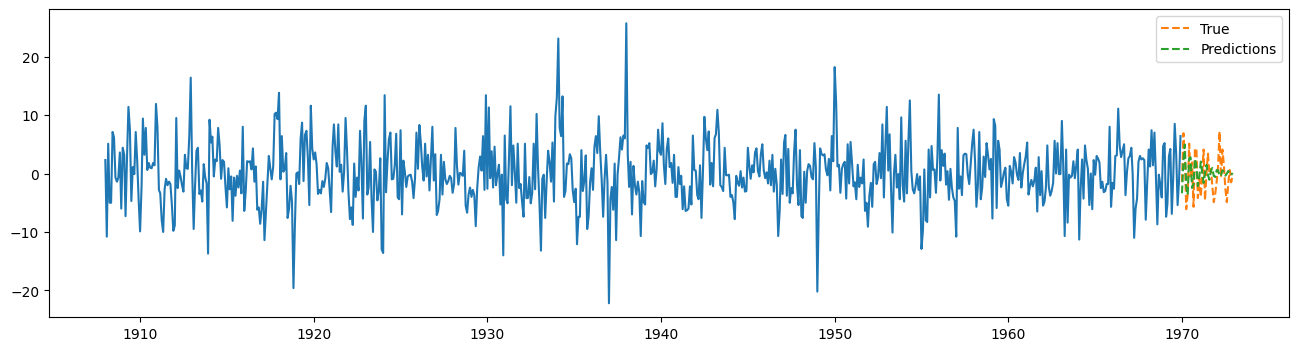

In [119]:
plt.figure(figsize=(16, 4))
plt.plot(train)
plt.plot(test, linestyle="--", label="True")
plt.plot(pred_summary['mean'], linestyle="--", label="Predictions")
plt.legend()

### **ARIMA**

The ARIMA model is denoted ARIMA($p$, $d$, $q$):
- $p$ is the order of the AR model
- $d$ is the number of times to difference the data
- $q$ is the order of the MA model
- $p$, $d$ and $q$ are nonnegative integers

In [120]:
# generate synthetic stationary data with an ARMA(1, 1) process
n = 250
ar_coeff = np.array([1, -0.7])
ma_coeff = np.array([1, 0.7])
arma_data = ss.tsa.arima_process.ArmaProcess(ar_coeff, ma_coeff).generate_sample(nsample=n, burnin=1000)

220


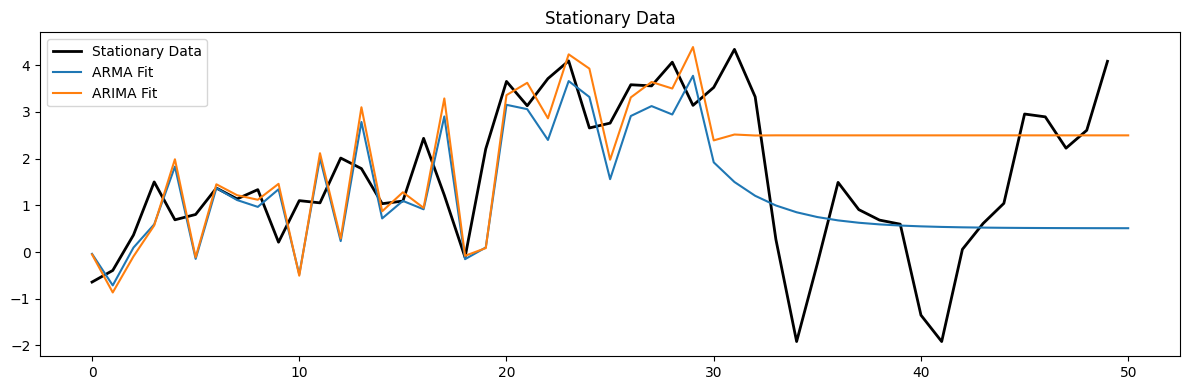

In [121]:
# fit model to stationary data
arma_model = ARIMA(arma_data[:-20], order=(1, 0, 1)).fit()
arima_model = ARIMA(arma_data[:-20], order=(1, 1, 1)).fit()

plt.figure(figsize=(12, 4))
plt.plot(arma_data[-50:], 'k', label='Stationary Data', linewidth=2)
plt.plot(arma_model.predict(200,250), label='ARMA Fit')
plt.plot(arima_model.predict(200, 250), label='ARIMA Fit')
plt.legend()
plt.title('Stationary Data')
plt.tight_layout();

print(len(arma_model.predict(10)))

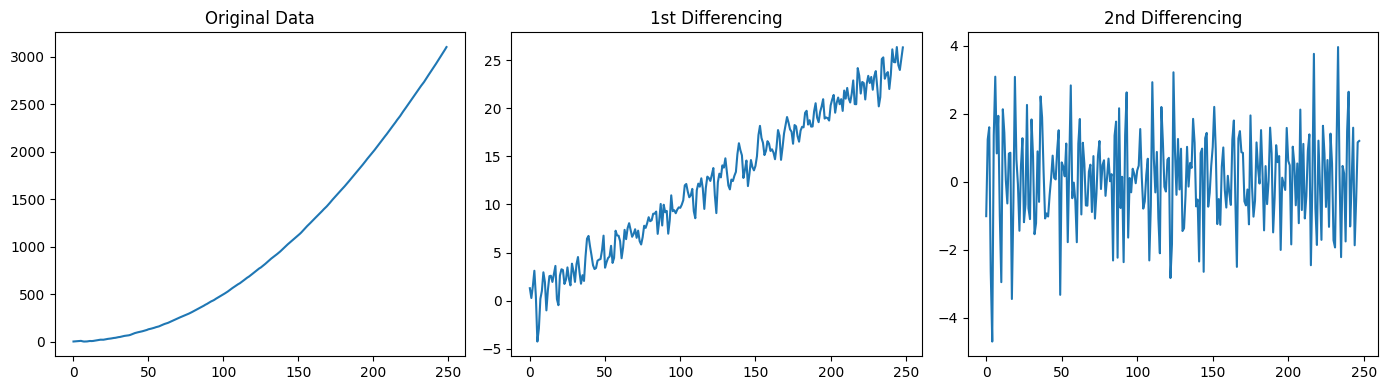

In [123]:
# generate a synthetic non-stationary data (needs to be differenced twice to be stationary)
t = np.arange(n)
non_stationary_data = 0.05 * t**2 + arma_data  # Quadratic trend

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(non_stationary_data)
axes[0].set_title('Original Data')
axes[1].plot(diff(non_stationary_data, k_diff=1))
axes[1].set_title('1st Differencing')
axes[2].plot(diff(non_stationary_data, k_diff=2))
axes[2].set_title('2nd Differencing')
plt.tight_layout();

c:\Users\Vlad Wero\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


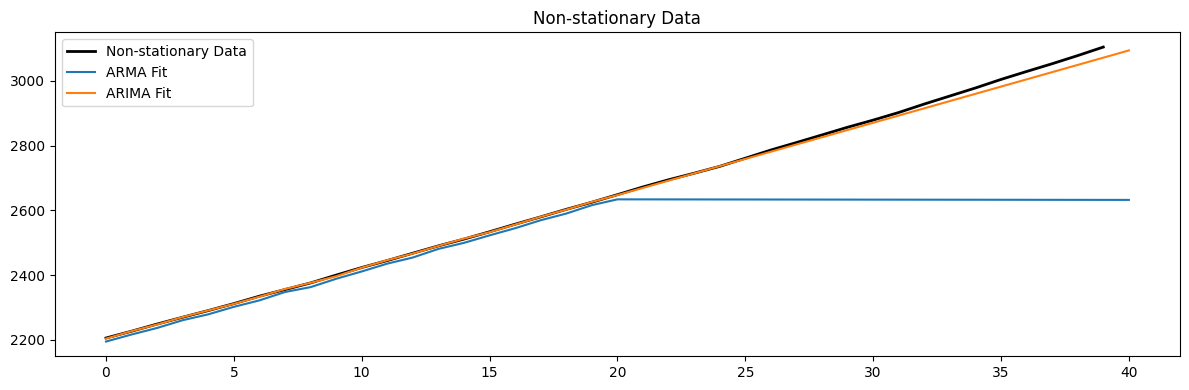

In [124]:
# fit models to non-stationary data
arma_model = ARIMA(non_stationary_data[:-20], order=(1, 0, 1)).fit()
arima_model = ARIMA(non_stationary_data[:-20], order=(1, 2, 1)).fit()

plt.figure(figsize=(12, 4))
plt.plot(non_stationary_data[-40:], 'k', label='Non-stationary Data', linewidth=2)
plt.plot(arma_model.predict(210,250), label='ARMA Fit')
plt.plot(arima_model.predict(210,250), label='ARIMA Fit')
plt.legend()
plt.title('Non-stationary Data')
plt.tight_layout();